<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/processingcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "mediapipe==0.10.21"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sttaseen/wlasl2000-resized")

print("Path to dataset files:", path)

In [ ]:
# Let's check how the missing videos affect class distribution
import json
import os
from collections import Counter

# The dataset was downloaded to the 'path' variable in the previous cell.
# We need to use this path to access the JSON file and video directory.
dataset_base_path = os.path.join(path, "wlasl-complete")
json_file_path = os.path.join(dataset_base_path, "WLASL_v0.3.json")
video_dir = os.path.join(dataset_base_path, "videos")

with open(json_file_path) as f:
    wlasl_data = json.load(f)

# Ensure the video directory exists before listing its contents
if not os.path.exists(video_dir):
    print(f"Error: Video directory not found at {video_dir}")
    # You might want to exit or handle this error differently
    available_ids = set() # No videos available
else:
    available_ids = set(f.replace('.mp4', '') for f in os.listdir(video_dir) if f.endswith('.mp4'))

# Count samples per class with ALL videos vs AVAILABLE videos
full_class_counts = Counter()
available_class_counts = Counter()

for entry in wlasl_data:
    gloss = entry["gloss"]
    for instance in entry["instances"]:
        video_id = str(instance["video_id"]).zfill(5)
        full_class_counts[gloss] += 1
        if video_id in available_ids:
            available_class_counts[gloss] += 1

print("Class distribution comparison:")
print(f"\nWith FULL dataset (21,083 videos):")
print(f"  Average samples/class: {21083 / 2000:.1f}")
print(f"  Classes with <5 samples: {sum(1 for c in full_class_counts.values() if c < 5)}")
print(f"  Classes with >=10 samples: {sum(1 for c in full_class_counts.values() if c >= 10)}")

print(f"\nWith AVAILABLE dataset (11,980 videos):")
print(f"  Average samples/class: {11980 / 2000:.1f}")
print(f"  Classes with <5 samples: {sum(1 for c in available_class_counts.values() if c < 5)}")
print(f"  Classes with >=10 samples: {sum(1 for c in available_class_counts.values() if c >= 10)}")
print(f"  Classes with ZERO samples: {sum(1 for c in available_class_counts.values() if c == 0)}")

In [ ]:
# Check what Kaggle says is in the dataset
import os

# Your Kaggle download path
kaggle_path = path

# List everything
print("Files in Kaggle dataset:")
for root, dirs, files in os.walk(path):
    print(f"\nDirectory: {root}")
    print(f"  Subdirectories: {dirs}")
    print(f"  Files: {len([f for f in files if f.endswith('.mp4')])} .mp4 files")

# Count videos
video_dir = f"{kaggle_path}/videos"
if os.path.exists(video_dir):
    videos = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]
    print(f"\nTotal .mp4 files in videos/: {len(videos)}")
else:
    print(f"Videos directory not found at {video_dir}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WLASL-2000 FULL DATASET - VALIDATION & SETUP
# ══════════════════════════════════════════════════════════════════════════════

import os
import json
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# The 'path' variable from the kagglehub download (first cell) points to the dataset root.
# We need to use this to construct the correct paths.
# path = '/kaggle/input/wlasl2000-resized'

# ── 1. SET YOUR PATHS ─────────────────────────────────────────────────────────

# Use the 'path' variable from the initial Kaggle download
# to ensure correct and dynamic pathing.
DATASET_ROOT = path # assuming 'path' is still available from first cell

VIDEO_DIR = os.path.join(DATASET_ROOT, "wlasl-complete", "videos")
JSON_PATH = os.path.join(DATASET_ROOT, "wlasl-complete", "WLASL_v0.3.json")

print("="*80)
print("STEP 1: VERIFY PATHS")
print("="*80)

# Check if paths exist
if os.path.exists(VIDEO_DIR):
    print(f"✓ Video directory found: {VIDEO_DIR}")
else:
    print(f"✗ Video directory NOT found: {VIDEO_DIR}")
    print("Please update VIDEO_DIR path")

if os.path.exists(JSON_PATH):
    print(f"✓ JSON file found: {JSON_PATH}")
else:
    print(f"✗ JSON file NOT found: {JSON_PATH}")
    print("Please update JSON_PATH")
    # Try to find it
    base_dir = Path(VIDEO_DIR).parent
    json_files = list(base_dir.glob("*.json"))
    if json_files:
        print(f"Found JSON files: {json_files}")

print()

# ── 2. COUNT VIDEO FILES ──────────────────────────────────────────────────────
print("="*80)
print("STEP 2: COUNT VIDEO FILES")
print("="*80)

video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')]
print(f"Total .mp4 files found: {len(video_files)}")
print(f"First 10 files: {sorted(video_files)[:10]}")
print(f"Last 10 files: {sorted(video_files)[-10:]}")

# Check file naming pattern
video_ids = set(f.replace('.mp4', '') for f in video_files)
print(f"\nVideo ID format check:")
print(f"  Shortest ID: {min(video_ids, key=len)}")
print(f"  Longest ID: {max(video_ids, key=len)}")
print(f"  Sample IDs: {sorted(list(video_ids))[:5]}")

print()

# ── 3. LOAD AND VALIDATE JSON ─────────────────────────────────────────────────
print("="*80)
print("STEP 3: LOAD AND VALIDATE JSON METADATA")
print("="*80)

with open(JSON_PATH, 'r') as f:
    wlasl_data = json.load(f)

print(f"Total entries in JSON: {len(wlasl_data)}")
print(f"Expected: 2000 sign classes")

# Check structure of first entry
first_entry = wlasl_data[0]
print(f"\nFirst entry structure:")
print(f"  Gloss (word): {first_entry.get('gloss', 'N/A')}")
print(f"  Number of instances: {len(first_entry.get('instances', []))}")
if first_entry.get('instances'):
    sample_instance = first_entry['instances'][0]
    print(f"  Sample instance keys: {list(sample_instance.keys())}")
    print(f"  Sample video_id: {sample_instance.get('video_id', 'N/A')}")

# Count total video instances in JSON
total_instances = sum(len(entry.get('instances', [])) for entry in wlasl_data)
print(f"\nTotal video instances in JSON: {total_instances}")

print()

# ── 4. MAP VIDEOS TO LABELS ───────────────────────────────────────────────────
print("="*80)
print("STEP 4: CREATE VIDEO \u2192 LABEL MAPPING")
print("="*80)

video_to_label = {}  # {video_id: (gloss, label_idx)}
label_map = {}       # {gloss: label_idx}
label_idx = 0

for entry in wlasl_data:
    gloss = entry['gloss']

    # Assign label index
    if gloss not in label_map:
        label_map[gloss] = label_idx
        label_idx += 1

    # Map each video to this label
    for instance in entry.get('instances', []):
        video_id = str(instance['video_id']).zfill(5)
        video_to_label[video_id] = (gloss, label_map[gloss])

print(f"Total unique sign classes: {len(label_map)}")
print(f"Total video entries in mapping: {len(video_to_label)}")
print(f"\nSample mappings:")
for i, (vid_id, (gloss, label)) in enumerate(list(video_to_label.items())[:5]):
    print(f"  {vid_id}.mp4 \u2192 '{gloss}' (label {label})")

print()

# ── 5. MATCH JSON TO ACTUAL FILES ─────────────────────────────────────────────
print("="*80)
print("STEP 5: MATCH JSON METADATA TO ACTUAL VIDEO FILES")
print("="*80)

# Find videos that exist on disk AND in JSON
matched_videos = []
videos_in_json_not_on_disk = []
videos_on_disk_not_in_json = []

for video_id in video_to_label.keys():
    video_file = f"{video_id}.mp4"
    if video_file in video_files:
        matched_videos.append(video_id)
    else:
        videos_in_json_not_on_disk.append(video_id)

for video_file in video_files:
    video_id = video_file.replace('.mp4', '')
    if video_id not in video_to_label:
        videos_on_disk_not_in_json.append(video_id)

print(f"✓ Videos matched (in JSON AND on disk): {len(matched_videos)}")
print(f"✗ Videos in JSON but NOT on disk: {len(videos_in_json_not_on_disk)}")
print(f"✗ Videos on disk but NOT in JSON: {len(videos_on_disk_not_in_json)}")

if videos_in_json_not_on_disk:
    print(f"\nFirst 10 missing videos: {videos_in_json_not_on_disk[:10]}")

if videos_on_disk_not_in_json:
    print(f"\nFirst 10 orphan videos: {videos_on_disk_not_in_json[:10]}")

print()

# ── 6. CLASS DISTRIBUTION ─────────────────────────────────────────────────────
print("="*80)
print("STEP 6: CLASS DISTRIBUTION ANALYSIS")
print("="*80)

# Count samples per class
class_counts = Counter()
for video_id in matched_videos:
    gloss, label = video_to_label[video_id]
    class_counts[label] += 1

print(f"Classes in matched videos: {len(class_counts)}")
print(f"Total samples: {sum(class_counts.values())}")
print(f"Average samples per class: {sum(class_counts.values()) / len(class_counts):.1f}")
print(f"Min samples: {min(class_counts.values())}")
print(f"Max samples: {max(class_counts.values())}")
print(f"Median samples: {np.median(list(class_counts.values())):.1f}")

# Distribution breakdown
print(f"\nDistribution breakdown:")
print(f"  Classes with <5 samples: {sum(1 for c in class_counts.values() if c < 5)}")
print(f"  Classes with 5-9 samples: {sum(1 for c in class_counts.values() if 5 <= c < 10)}")
print(f"  Classes with >=10 samples: {sum(1 for c in class_counts.values() if c >= 10)}")
print(f"  Classes with >=20 samples: {sum(1 for c in class_counts.values() if c >= 20)}")

# Find most and least represented classes
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
label_map_inv = {v: k for k, v in label_map.items()}

print(f"\nMost represented classes:")
for label, count in sorted_classes[:5]:
    print(f"  '{label_map_inv[label]}': {count} samples")

print(f"\nLeast represented classes:")
for label, count in sorted_classes[-5:]:
    print(f"  '{label_map_inv[label]}': {count} samples")

print()

# ── 7. VIDEO QUALITY CHECK ────────────────────────────────────────────────────
print("="*80)
print("STEP 7: VIDEO QUALITY CHECK (Sample)")
print("="*80)

# Test opening a few videos
sample_ids = sorted(matched_videos)[:10]
readable_count = 0
unreadable = []

for video_id in sample_ids:
    video_path = os.path.join(VIDEO_DIR, f"{video_id}.mp4")
    cap = cv2.VideoCapture(video_path)

    if cap.isOpened():
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        gloss, label = video_to_label[video_id]
        print(f"✓ {video_id}.mp4 - '{gloss}' - {frame_count} frames, {fps} fps, {width}x{height}")
        readable_count += 1
    else:
        gloss, label = video_to_label[video_id]
        print(f"✗ {video_id}.mp4 - '{gloss}' - CANNOT OPEN")
        unreadable.append(video_id)

    cap.release()

print(f"\nReadable: {readable_count}/{len(sample_ids)}")
if unreadable:
    print(f"Unreadable videos: {unreadable}")

print()

# ── 8. FINAL SUMMARY ──────────────────────────────────────────────────────────
print("="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"""
Dataset: WLASL-2000 Full
Location: {VIDEO_DIR}

Video Files:
  • Total .mp4 files on disk: {len(video_files)}
  • Videos matched with JSON labels: {len(matched_videos)}
  • Videos missing from disk: {len(videos_in_json_not_on_disk)}
  • Orphan videos (no label): {len(videos_on_disk_not_in_json)}

Classes:
  • Total sign classes: {len(class_counts)}
  • Expected (WLASL-2000): 2000
  • Average samples/class: {sum(class_counts.values()) / len(class_counts):.1f}

Data Quality:
  • Classes with >=10 samples: {sum(1 for c in class_counts.values() if c >= 10)}
  • Classes with <5 samples: {sum(1 for c in class_counts.values() if c < 5)}
  • Sample videos readable: {readable_count}/{len(sample_ids)}

Ready for Processing: {'✓ YES' if len(matched_videos) > 20000 else '✗ NO - Check issues above'}
""")

# ── 9. SAVE METADATA ──────────────────────────────────────────────────────────
print("="*80)
print("STEP 9: SAVE METADATA FOR PROCESSING")
print("="*80)

metadata = {
    'video_dir': VIDEO_DIR,
    'json_path': JSON_PATH,
    'matched_videos': matched_videos,
    'video_to_label': video_to_label,
    'label_map': label_map,
    'label_map_inv': label_map_inv,
    'class_counts': dict(class_counts),
    'total_videos': len(matched_videos),
    'total_classes': len(class_counts)
}

# Save to JSON
with open('wlasl_full_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Metadata saved to: wlasl_full_metadata.json")

# Create a simple CSV for reference
import csv
with open('wlasl_full_video_list.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['video_id', 'video_path', 'gloss', 'label'])
    for video_id in sorted(matched_videos):
        gloss, label = video_to_label[video_id]
        video_path = os.path.join(VIDEO_DIR, f"{video_id}.mp4")
        writer.writerow([video_id, video_path, gloss, label])

print("✓ Video list saved to: wlasl_full_video_list.csv")

print("\n" + "="*80)
print("VALIDATION COMPLETE!")
print("="*80)


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from concurrent.futures import ThreadPoolExecutor, as_completed


In [ ]:

import json
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
from tqdm import tqdm

In [ ]:
with open('wlasl_full_metadata.json', 'r') as f:
    metadata = json.load(f)

video_dir = metadata['video_dir']
matched_videos = metadata['matched_videos']
video_to_label = metadata['video_to_label']

print(f"Loaded metadata for {len(matched_videos)} videos")


In [ ]:
import json
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
from tqdm import tqdm
import time
from datetime import datetime, timedelta

In [ ]:
VIDEO_DIR = "/root/.cache/kagglehub/datasets/sttaseen/wlasl2000-resized/versions/1/wlasl-complete/videos"


In [ ]:
import kagglehub
_path = kagglehub.dataset_download("sttaseen/wlasl2000-resized")
VIDEO_DIR = os.path.join(_path, "wlasl-complete", "videos")
print(f"VIDEO_DIR resolved to: {VIDEO_DIR}")
print(f"Files present: {len([f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')])}")

In [ ]:
import cv2
import os

VIDEO_DIR = "/kaggle/input/wlasl2000-resized/wlasl-complete/videos"

# Test 1: Can cv2 open and read a frame?
test_file = os.path.join(VIDEO_DIR, "00295.mp4")
print(f"File exists: {os.path.exists(test_file)}")
print(f"File size: {os.path.getsize(test_file)} bytes")

cap = cv2.VideoCapture(test_file)
print(f"cap.isOpened(): {cap.isOpened()}")

ret, frame = cap.read()
print(f"First frame read: ret={ret}, frame shape={frame.shape if frame is not None else None}")
cap.release()

In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIXED PROCESSING - with lower confidence thresholds
# ══════════════════════════════════════════════════════════════════════════════

import json
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
from tqdm import tqdm
import time
from datetime import datetime, timedelta

# Load metadata
with open('wlasl_full_metadata.json', 'r') as f:
    metadata = json.load(f)

matched_videos = metadata['matched_videos']
video_to_label = {k: tuple(v) for k, v in metadata['video_to_label'].items()}

print(f"Loaded metadata for {len(matched_videos)} videos")
print(f"Video directory: {VIDEO_DIR}")

# Constants
SEQ_LEN = 30
HAND_FEATURES = 21 * 3
NUM_FEATURES = HAND_FEATURES * 2
MOTION_FEATURES = NUM_FEATURES * 3
MODEL_PATH = "hand_landmarker.task"

# Helper functions
def sample_frame_indices(num_frames, seq_len=30):
    if num_frames <= 0:
        return np.zeros(seq_len, dtype=int)
    if num_frames < seq_len:
        indices = np.linspace(0, num_frames - 1, seq_len, dtype=int)
        indices[indices >= num_frames] = num_frames - 1
        return indices
    return np.linspace(0, num_frames - 1, seq_len, dtype=int)

def add_motion_features(sequence):
    velocity = np.diff(sequence, axis=0, prepend=sequence[:1])
    acceleration = np.diff(velocity, axis=0, prepend=velocity[:1])
    return np.concatenate([sequence, velocity, acceleration], axis=1).astype(np.float32)

def extract_video_sequence(video_path, detector, seq_len=SEQ_LEN):
    """Extract hand landmarks from video - FIXED VERSION."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.zeros((seq_len, MOTION_FEATURES), dtype=np.float32), False

    good_frames = []
    frame_count = 0

    while cap.isOpened() and len(good_frames) < seq_len * 2:  # Get more frames than needed
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        try:
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
            result = detector.detect(mp_image)

            left_hand = np.zeros(HAND_FEATURES, dtype=np.float32)
            right_hand = np.zeros(HAND_FEATURES, dtype=np.float32)

            if result.hand_landmarks:
                for hand_landmarks, handedness in zip(result.hand_landmarks, result.handedness):
                    hand_label = handedness[0].category_name
                    landmarks_flat = []
                    for landmark in hand_landmarks:
                        landmarks_flat.extend([landmark.x, landmark.y, landmark.z])
                    landmarks_array = np.array(landmarks_flat, dtype=np.float32)

                    if hand_label == "Left":
                        left_hand = landmarks_array
                    elif hand_label == "Right":
                        right_hand = landmarks_array

            if not (np.all(left_hand == 0) and np.all(right_hand == 0)):
                combined = np.concatenate([left_hand, right_hand])
                good_frames.append(combined)

        except Exception as e:
            # Skip problematic frames
            continue

    cap.release()

    if len(good_frames) == 0:
        return np.zeros((seq_len, MOTION_FEATURES), dtype=np.float32), False

    good_frames = np.array(good_frames)

    # Sample to exact length
    if len(good_frames) < seq_len:
        pad = np.repeat(good_frames[-1:], seq_len - len(good_frames), axis=0)
        good_frames = np.vstack([good_frames, pad])
    elif len(good_frames) > seq_len:
        indices = sample_frame_indices(len(good_frames), seq_len)
        good_frames = good_frames[indices]

    return add_motion_features(good_frames), True

# Multi-threaded processing - FIXED
def batch_extract_threaded(
    video_ids,
    video_dir,
    video_to_label,
    seq_len=SEQ_LEN,
    save_path="wlasl_embeddings_FULL_21k_FIXED2.npz",
    num_workers=11,
):
    n_videos = len(video_ids)
    X = np.zeros((n_videos, seq_len, MOTION_FEATURES), dtype=np.float32)
    y = np.zeros(n_videos, dtype=np.int32)

    start_time = time.time()
    completed = 0
    successful = 0
    failed = 0

    lock = threading.Lock()
    thread_local = threading.local()

    def get_detector():
        """FIXED: Properly create detector per thread."""
        if not hasattr(thread_local, "detector"):
            options = vision.HandLandmarkerOptions(
                base_options=python.BaseOptions(model_asset_path=MODEL_PATH),
                running_mode=vision.RunningMode.IMAGE,
                num_hands=2,
                min_hand_detection_confidence=0.1,      # LOWERED
                min_hand_presence_confidence=0.1,       # ADDED
                min_tracking_confidence=0.1,             # LOWERED
            )
            thread_local.detector = vision.HandLandmarker.create_from_options(options)
        return thread_local.detector

    def process_video(idx):
        video_id = video_ids[idx]
        video_path = f"{video_dir}/{video_id}.mp4"
        gloss, label = video_to_label[video_id]

        try:
            detector = get_detector()
            sequence, success = extract_video_sequence(video_path, detector, seq_len)
            return idx, sequence, label, success, video_id
        except Exception as e:
            return idx, np.zeros((seq_len, MOTION_FEATURES), dtype=np.float32), label, False, video_id

    print(f"Starting processing of {n_videos} videos...")

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(process_video, i) for i in range(n_videos)]

        with tqdm(total=n_videos, desc="Processing") as pbar:
            for future in as_completed(futures):
                idx, sequence, label, success, video_id = future.result()

                with lock:
                    X[idx] = sequence
                    y[idx] = label
                    completed += 1

                    if success:
                        successful += 1
                    else:
                        failed += 1

                    pbar.update(1)

                    if completed % 1000 == 0:
                        elapsed = time.time() - start_time
                        rate = completed / elapsed
                        print(f"\n[{completed}/{n_videos}] Success: {successful}, Failed: {failed}, Rate: {rate:.1f} vid/s")

    # Save
    np.savez_compressed(save_path, X=X, y=y)

    elapsed = time.time() - start_time
    print(f"\n✓ Complete: {successful} successful, {failed} failed in {timedelta(seconds=int(elapsed))}")
    print(f"✓ Saved to {save_path}")

    return X, y

# Run
X, y = batch_extract_threaded(
    video_ids=matched_videos,
    video_dir=VIDEO_DIR,
    video_to_label=video_to_label,
    save_path="wlasl_embeddings_FULL_21k_FIXED2.npz",
    num_workers=11
)

print("\n🎉 DONE! Verify embeddings:")
non_zero = np.sum(X != 0)
print(f"Non-zero values: {non_zero:,} / {X.size:,} ({100*non_zero/X.size:.1f}%)")

In [ ]:
# Check what's in the loaded metadata
import json

with open('wlasl_full_metadata.json', 'r') as f:
    metadata = json.load(f)

# Check a few video_to_label entries
video_to_label = metadata['video_to_label']
print("Sample video_to_label entries:")
for i, (vid, info) in enumerate(list(video_to_label.items())[:10]):
    print(f"  {vid}: {info}")

# Check unique labels
labels_in_metadata = set(info[1] for info in video_to_label.values())
print(f"\nUnique labels in metadata: {len(labels_in_metadata)}")
print(f"Should be: 2000")

# If broken, check label_map
label_map = metadata.get('label_map', {})
print(f"\nUnique classes in label_map: {len(label_map)}")
print(f"First 5 entries: {dict(list(label_map.items())[:5])}")

In [ ]:
data = np.load("wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

from collections import Counter
class_counts = Counter(y)

print(f"Total samples: {len(y)}")
print(f"Total classes: {len(class_counts)}")
print(f"Samples per class - min: {min(class_counts.values())}, max: {max(class_counts.values())}, avg: {len(y)/len(class_counts):.1f}")
print(f"\nClasses with <3 samples: {sum(1 for c in class_counts.values() if c < 3)}")
print(f"Classes with <5 samples: {sum(1 for c in class_counts.values() if c < 5)}")
print(f"Classes with >=10 samples: {sum(1 for c in class_counts.values() if c >= 10)}")

In [ ]:
unique_classes = np.unique(y)
print(f"Classes in  videos: {len(unique_classes)}")
print(f"Classes: {[label_map_inv[i] for i in unique_classes]}")

In [ ]:
# # Remap labels to 0..N for only the classes present
# class_remap = {old: new for new, old in enumerate(unique_classes)}
# y_remapped  = np.array([class_remap[label] for label in y])
# num_classes = len(unique_classes)

# print(f"Remapped to {num_classes} classes")

# # Rebuild label map for decoding predictions later
# label_map_inv_remapped = {new: label_map_inv[old] for old, new in class_remap.items()}

In [ ]:
# Labels are already 0-1999, use directly
num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")
print(f"Label range: {y.min()} to {y.max()}")

# Load the label map from metadata (for decoding predictions later)
import json
with open('wlasl_full_metadata.json', 'r') as f:
    metadata = json.load(f)

label_map_inv = metadata.get('label_map_inv', {})
# Convert string keys to int
label_map_inv = {int(k): v for k, v in label_map_inv.items()}

print(f"Loaded label map with {len(label_map_inv)} classes")
print(f"Sample: {list(label_map_inv.items())[:5]}")

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, 30, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]



In [ ]:
import os

file_path = "/content/drive/MyDrive/wlasl_embeddings_FULL_21k_FIXED2_offical.npz"

print("Exists:", os.path.exists(file_path))
print("Size:", os.path.getsize(file_path) if os.path.exists(file_path) else "missing")

with open(file_path, "rb") as f:
    print(f.read(32))

In [ ]:
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
def augment_sequence(sequence, num_augments=2):  # was 4
    augmented = [sequence]

    for _ in range(num_augments):
        aug = sequence.copy()

        # Gentler noise
        aug = aug + np.random.randn(*aug.shape) * 0.01  # was 0.02

        # Less extreme time stretch
        stretch_factor = np.random.uniform(0.85, 1.15)  # was 0.7-1.3
        orig_len = len(aug)
        new_len = int(orig_len * stretch_factor)
        indices = np.linspace(0, orig_len - 1, new_len).astype(int)
        aug = aug[indices]
        indices = np.linspace(0, len(aug) - 1, orig_len).astype(int)
        aug = aug[indices]

        # Less aggressive frame dropout
        dropout_frames = np.random.choice(orig_len, size=2, replace=False)  # was 3
        aug[dropout_frames] = 0

        # Keep hand mirroring but less often
        if np.random.random() > 0.7:  # was 0.5
            left = aug[:, :63].copy()
            right = aug[:, 63:126].copy()
            aug[:, :63] = right
            aug[:, 63:126] = left
            aug[:, 126:189], aug[:, 189:252] = aug[:, 189:252].copy(), aug[:, 126:189].copy()
            aug[:, 252:315], aug[:, 315:378] = aug[:, 315:378].copy(), aug[:, 252:315].copy()

        # Gentler rotation
        angle = np.random.uniform(-10, 10) * np.pi / 180  # was -15 to 15
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        for start in [0, 63]:
            x = aug[:, start:start+63:3].copy()
            y = aug[:, start+1:start+63:3].copy()
            aug[:, start:start+63:3] = x * cos_a - y * sin_a
            aug[:, start+1:start+63:3] = x * sin_a + y * cos_a

        augmented.append(aug.astype(np.float32))

    return augmented

In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# # SAVE EMBEDDINGS TO GOOGLE DRIVE
# # ══════════════════════════════════════════════════════════════════════════════

# # Step 1: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Step 2: Create a folder for your project (optional but recommended)
# import os
# drive_path = "/content/drive/MyDrive/ASL_Project"
# os.makedirs(drive_path, exist_ok=True)

# # Step 3: Copy your files to Drive
# import shutil

# files_to_save = [
#     "wlasl_embeddings_FULL_21k_FIXED2.npz",
#     "wlasl_full_metadata.json",
# ]

# for filename in files_to_save:
#     if os.path.exists(filename):
#         dest = os.path.join(drive_path, filename)
#         shutil.copy(filename, dest)
#         size_mb = os.path.getsize(dest) / (1024 * 1024)
#         print(f"✓ Saved {filename} → {dest} ({size_mb:.1f} MB)")
#     else:
#         print(f"✗ Not found: {filename}")

# print(f"\nAll files saved to: {drive_path}")

In [2]:
import numpy as np
drive_path = "/content/drive/MyDrive/ASL_Project"

# Load directly from Drive
data = np.load(f"{drive_path}/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

In [ ]:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SignLSTM(nn.Module):
    def __init__(self, input_size=378, hidden_size=512,  # ← 512 not 256
                 num_layers=2, num_classes=2000, dropout=0.5):  # ← 2 layers, 0.5 dropout
        super().__init__()
        self.pos_encoding = PositionalEncoding(d_model=input_size, max_len=30)
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout, bidirectional=True,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size*2, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_size*2))
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size*2),
            nn.Linear(hidden_size*2, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.pos_encoding(x)
        out, _ = self.lstm(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        out = self.transformer(torch.cat([cls, out], dim=1))
        return self.classifier(out[:, 0, :])

import numpy as np

def augment_sequence(sequence, num_augments=2):
    """
    Safer augmentation for sign landmarks:
    - small gaussian noise
    - mild temporal resampling
    - mild xy rotation
    NO mirroring
    NO zero-frame dropout
    """
    augmented = [sequence.astype(np.float32).copy()]
    T, F = sequence.shape

    for _ in range(num_augments):
        aug = sequence.astype(np.float32).copy()

        # 1. Small gaussian noise
        aug += np.random.normal(0, 0.005, size=aug.shape).astype(np.float32)

        # 2. Mild time stretch / compression
        stretch_factor = np.random.uniform(0.95, 1.05)
        new_len = max(2, int(T * stretch_factor))

        idx = np.linspace(0, T - 1, new_len)
        idx = np.clip(idx.astype(np.int32), 0, T - 1)
        aug = aug[idx]

        # Resample back to original length
        idx_back = np.linspace(0, len(aug) - 1, T)
        idx_back = np.clip(idx_back.astype(np.int32), 0, len(aug) - 1)
        aug = aug[idx_back]

        # 3. Mild rotation only on x,y of hand landmarks
        angle = np.random.uniform(-5, 5) * np.pi / 180.0
        cos_a, sin_a = np.cos(angle), np.sin(angle)

        # Rotate first 126 dims only if those are left/right hand xyz landmarks
        # (x,y,z repeated)
        for start in [0, 63]:
            x_coords = aug[:, start:start+63:3].copy()
            y_coords = aug[:, start+1:start+63:3].copy()

            aug[:, start:start+63:3] = x_coords * cos_a - y_coords * sin_a
            aug[:, start+1:start+63:3] = x_coords * sin_a + y_coords * cos_a

        augmented.append(aug.astype(np.float32))

    return augmented


# Sanity check
print("✓ SignLSTM class defined")
print("✓ augment_sequence function defined")
model_test = SignLSTM(num_classes=2000)
print(f"✓ Model test: {sum(p.numel() for p in model_test.parameters()):,} parameters")

In [ ]:
def top_k_accuracy(logits, targets, k=5):
    topk = logits.topk(k, dim=1).indices
    correct = topk.eq(targets.view(-1, 1)).any(dim=1)
    return correct.float().mean().item()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONSERVATIVE IMPROVEMENT - Minimum changes to proven baseline
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from collections import Counter

# Load data
print("="*80 + "\nLOADING DATA\n" + "="*80)
data = np.load("wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]
num_classes = len(np.unique(y))

# Split & augment (same as before)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_aug, y_aug = [], []
for seq, label in zip(X_train_raw, y_train_raw):
    for version in augment_sequence(seq, num_augments=4):
        X_aug.append(version)
        y_aug.append(label)

X_aug = np.array(X_aug, dtype=np.float32)
y_aug = np.array(y_aug, dtype=np.int64)

# Tensors
X_train_tensor = torch.tensor(X_aug, dtype=torch.float32)
y_train_tensor = torch.tensor(y_aug, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_raw, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_raw, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

from collections import Counter
import torch
import numpy as np

class_counts = Counter(y_aug.tolist())
sample_weights = np.array([1.0 / class_counts[label] for label in y_aug], dtype=np.float32)

sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=128, sampler=sampler)

# train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

train_size = len(train_ds)
val_size = len(val_ds)

# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SignLSTM(num_classes=num_classes).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# ★ SIMPLE SETUP + MIXUP (the only proven addition)
criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)  # ★ AdamW
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=80,
    eta_min=1e-6
)
print(scheduler)

EPOCHS = 200  # ★ Longer training
best_val_acc = 0
best_epoch = 0

# ★ Mixup (the ONE extra improvement)
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

print(f"Setup: CrossEntropy + AdamW + Mixup(30%) + {EPOCHS} epochs")

# Training loop
print("\n" + "="*80 + "\nTRAINING\n" + "="*80)

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        if np.random.random() < 0.3:
            mixed_X, y_a, y_b, lam = mixup_data(X_batch, y_batch, alpha=0.2)
            logits = model(mixed_X)
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        else:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            clean_logits = model(X_batch)
            train_correct += (clean_logits.argmax(1) == y_batch).sum().item()
            train_total += y_batch.size(0)

    train_acc = train_correct / train_total


    model.eval()
    val_loss, val_correct, val_top5_sum = 0, 0,0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item()
            val_correct += (logits.argmax(1) == y_batch).sum().item()


    # train_acc = train_correct / train_size
    val_acc = val_correct / val_size
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train: {train_acc:.3f} | Val: {val_acc:.3f} | Loss: {avg_val_loss:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'num_classes': num_classes,
        }, "sign_lstm_best.pt")
        print(f"  ↑ Best: {best_val_acc:.3f}")

print(f"\nBest: {best_val_acc:.3f} at epoch {best_epoch}")

## combining models

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from collections import Counter
import shutil, os

# ── Model ─────────────────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SignLSTM(nn.Module):
    def __init__(self, input_size=378, hidden_size=512,
                 num_layers=2, num_classes=2000, dropout=0.5):
        super().__init__()
        self.pos_encoding = PositionalEncoding(d_model=input_size, max_len=30)
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout, bidirectional=True,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size*2, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_size*2))
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size*2),
            nn.Linear(hidden_size*2, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.pos_encoding(x)
        out, _ = self.lstm(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        out = self.transformer(torch.cat([cls, out], dim=1))
        return self.classifier(out[:, 0, :])

# ── Augmentation ──────────────────────────────────────────────────────────────
def augment_sequence(sequence, num_augments=4):
    augmented = [sequence.copy()]
    for _ in range(num_augments):
        aug = sequence.copy()
        aug = aug + np.random.randn(*aug.shape) * 0.01
        stretch  = np.random.uniform(0.85, 1.15)
        orig_len = len(aug)
        idx      = np.linspace(0, orig_len-1, int(orig_len*stretch)).astype(int)
        aug      = aug[idx]
        idx      = np.linspace(0, len(aug)-1, orig_len).astype(int)
        aug      = aug[idx]
        drop     = np.random.choice(orig_len, size=2, replace=False)
        aug[drop] = 0
        if np.random.random() > 0.7:
            l, r = aug[:, :63].copy(), aug[:, 63:126].copy()
            aug[:, :63], aug[:, 63:126] = r, l
            aug[:, 126:189], aug[:, 189:252] = aug[:, 189:252].copy(), aug[:, 126:189].copy()
            aug[:, 252:315], aug[:, 315:378] = aug[:, 315:378].copy(), aug[:, 252:315].copy()
        angle    = np.random.uniform(-10, 10) * np.pi / 180
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        for start in [0, 63]:
            xc = aug[:, start:start+63:3].copy()
            yc = aug[:, start+1:start+63:3].copy()
            aug[:, start:start+63:3]   = xc*cos_a - yc*sin_a
            aug[:, start+1:start+63:3] = xc*sin_a + yc*cos_a
        augmented.append(aug.astype(np.float32))
    return augmented

# ── Helper: run one epoch ─────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None, device='cuda'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / len(loader), correct / total

# ── Verify model size ─────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_test  = SignLSTM(num_classes=2000)
print(f"✓ Model params (2000 classes): {sum(p.numel() for p in _test.parameters()):,}")
del _test
print(f"✓ Device: {device}")
print(f"✓ All functions defined")

✓ Model params (2000 classes): 28,306,896
✓ Device: cuda
✓ All functions defined


/tmp/ipykernel_33829/2010764927.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIXED DATA SETUP - Handle singleton classes after dedup
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from collections import Counter

data = np.load("wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

print(f"Raw dataset: {len(X)} videos")

# ── Step 1: Remove duplicate embeddings ───────────────────────────────────────
print("Removing duplicate embeddings...")
_, unique_idx = np.unique(X.reshape(len(X), -1), axis=0, return_index=True)
unique_idx    = np.sort(unique_idx)
X_clean = X[unique_idx]
y_clean = y[unique_idx]
print(f"After dedup: {len(X_clean)} videos (removed {len(X)-len(X_clean)})")

# ── Step 2: Remove classes with only 1 sample (can't stratify) ───────────────
class_counts_clean = Counter(y_clean.tolist())
singleton_classes  = {c for c, cnt in class_counts_clean.items() if cnt < 2}
print(f"Singleton classes after dedup: {len(singleton_classes)}")

if singleton_classes:
    keep_mask = ~np.isin(y_clean, list(singleton_classes))
    X_clean   = X_clean[keep_mask]
    y_clean   = y_clean[keep_mask]
    print(f"After removing singletons: {len(X_clean)} videos, "
          f"{len(np.unique(y_clean))} classes")

# ── Step 3: ONE master split ──────────────────────────────────────────────────
X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=42, stratify=y_clean
)
print(f"\nMaster split: {len(X_train_all)} train | {len(X_val_all)} val")

# ── Step 4: Label remapping ───────────────────────────────────────────────────
all_classes      = sorted(np.unique(y_clean).tolist())
remap_full       = {old: new for new, old in enumerate(all_classes)}
num_classes_full = len(all_classes)

y_full_train = np.array([remap_full[l] for l in y_train_all], dtype=np.int64)
y_full_val   = np.array([remap_full[l] for l in y_val_all],   dtype=np.int64)
print(f"Full dataset classes: {num_classes_full}")

# ── Step 5: Phase 1 subset (≥10 samples in TRAIN only) ───────────────────────
train_counts  = Counter(y_train_all.tolist())
valid_p1      = sorted([c for c, cnt in train_counts.items() if cnt >= 10])

train_mask_p1 = np.isin(y_train_all, valid_p1)
val_mask_p1   = np.isin(y_val_all,   valid_p1)

X_p1_train    = X_train_all[train_mask_p1]
y_p1_train    = y_train_all[train_mask_p1]
X_p1_val      = X_val_all[val_mask_p1]
y_p1_val      = y_val_all[val_mask_p1]

remap_p1      = {old: new for new, old in enumerate(valid_p1)}
y_p1_train_m  = np.array([remap_p1[l] for l in y_p1_train], dtype=np.int64)
y_p1_val_m    = np.array([remap_p1[l] for l in y_p1_val],   dtype=np.int64)

print(f"\nPhase 1: {len(X_p1_train)} train | {len(X_p1_val)} val | {len(valid_p1)} classes")
print(f"Phase 2: {len(X_train_all)} train | {len(X_val_all)} val | {num_classes_full} classes")

# ── Step 6: Verify NO leakage ─────────────────────────────────────────────────
p1_set  = set(map(lambda x: x.tobytes(), X_p1_train))
val_set = set(map(lambda x: x.tobytes(), X_val_all))
overlap = len(p1_set & val_set)
print(f"\nLeakage check: {overlap} overlapping samples")
print(f"{'✓ NO LEAKAGE' if overlap == 0 else '❌ STILL HAS LEAKAGE'}")

# ── Step 7: Build loaders ─────────────────────────────────────────────────────
def make_loader(X_tr, X_val, y_tr, y_val, num_augments=4, batch_size=128):
    Xa, ya = [], []
    for seq, label in zip(X_tr, y_tr):
        for v in augment_sequence(seq, num_augments=num_augments):
            Xa.append(v)
            ya.append(label)
    X_aug = np.array(Xa, dtype=np.float32)
    y_aug = np.array(ya, dtype=np.int64)
    tl = DataLoader(TensorDataset(
            torch.tensor(X_aug, dtype=torch.float32),
            torch.tensor(y_aug, dtype=torch.long)),
        batch_size=batch_size, shuffle=True)
    vl = DataLoader(TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.long)),
        batch_size=batch_size, shuffle=False)
    return tl, vl, len(X_aug), len(X_val)

print("\nBuilding Phase 1 loaders...")
train_loader_1, val_loader_1, train_size_1, val_size_1 = make_loader(
    X_p1_train, X_p1_val, y_p1_train_m, y_p1_val_m, num_augments=4
)
print(f"✓ Phase 1: train={train_size_1}, val={val_size_1}")

print("Building Phase 2/3 loaders (num_augments=2)...")
train_loader_2, val_loader_2, train_size_2, val_size_2 = make_loader(
    X_train_all, X_val_all, y_full_train, y_full_val, num_augments=2
)
print(f"✓ Phase 2/3: train={train_size_2}, val={val_size_2}")
print("\n✓ All loaders ready!")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: ALL THREE PHASES - Clean, no leakage
# ══════════════════════════════════════════════════════════════════════════════

import shutil, os
from sklearn.metrics import top_k_accuracy_score

DRIVE_PATH = "/content/drive/MyDrive/ASL_Project"
os.makedirs(DRIVE_PATH, exist_ok=True)

# ════════════════════════════════════════════════════════════
# PHASE 1: Train on well-represented classes
# ════════════════════════════════════════════════════════════
print("="*70)
print(f"PHASE 1: {len(valid_p1)} classes | 100 epochs")
print("="*70)

model      = SignLSTM(input_size=378, num_classes=len(valid_p1)).to(device)
criterion1 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer1 = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer1, T_0=30, T_mult=2, eta_min=1e-6
)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

best_p1 = 0
for epoch in range(100):
    tr_loss, tr_acc = run_epoch(model, train_loader_1, criterion1, optimizer1, device)
    vl_loss, vl_acc = run_epoch(model, val_loader_1,   criterion1, None,       device)
    scheduler1.step()
    print(f"P1 {epoch+1:03d}/100 | Train: {tr_acc:.3f} | Val: {vl_acc:.3f} | Loss: {vl_loss:.4f}")
    if vl_acc > best_p1:
        best_p1 = vl_acc
        torch.save(model.state_dict(), "phase1_best.pt")
        shutil.copy("phase1_best.pt", f"{DRIVE_PATH}/phase1_best.pt")
        print(f"  ↑ Best: {best_p1:.3f} (saved)")

print(f"\n✓ Phase 1 done. Best: {best_p1:.3f}")

# ════════════════════════════════════════════════════════════
# PHASE 2: Swap head to full classes, freeze backbone
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(f"PHASE 2: {num_classes_full} classes, backbone frozen | 20 epochs")
print("="*70)

model.load_state_dict(torch.load("phase1_best.pt"))
model.classifier[-1] = nn.Linear(512, num_classes_full).to(device)

for name, param in model.named_parameters():
    param.requires_grad = "classifier" in name

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} (backbone frozen)")

criterion2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4, weight_decay=1e-4
)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=20, eta_min=1e-6
)

best_p2 = 0
for epoch in range(20):
    tr_loss, tr_acc = run_epoch(model, train_loader_2, criterion2, optimizer2, device)
    vl_loss, vl_acc = run_epoch(model, val_loader_2,   criterion2, None,       device)
    scheduler2.step()
    print(f"P2 {epoch+1:02d}/20 | Train: {tr_acc:.3f} | Val: {vl_acc:.3f} | Loss: {vl_loss:.4f}")
    if vl_acc > best_p2:
        best_p2 = vl_acc
        torch.save(model.state_dict(), "phase2_best.pt")
        shutil.copy("phase2_best.pt", f"{DRIVE_PATH}/phase2_best.pt")
        print(f"  ↑ Best: {best_p2:.3f} (saved)")

print(f"\n✓ Phase 2 done. Best: {best_p2:.3f}")

# ════════════════════════════════════════════════════════════
# PHASE 3: Full fine-tune, all layers
# ════════════════════════════════════════════════════════════
print("\n" + "="*70)
print(f"PHASE 3: {num_classes_full} classes, all layers | 120 epochs")
print("="*70)

model.load_state_dict(torch.load("phase2_best.pt"))
for param in model.parameters():
    param.requires_grad = True
print(f"All {sum(p.numel() for p in model.parameters()):,} params unfrozen")

optimizer3 = torch.optim.Adam([
    {'params': [p for n, p in model.named_parameters()
                if 'classifier' not in n], 'lr': 3e-5},
    {'params': model.classifier.parameters(),             'lr': 1e-4},
], weight_decay=1e-4)
scheduler3 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer3, T_0=40, T_mult=1, eta_min=1e-6
)
criterion3 = nn.CrossEntropyLoss(label_smoothing=0.1)

best_p3, best_ep3 = best_p2, 0
for epoch in range(120):
    tr_loss, tr_acc = run_epoch(model, train_loader_2, criterion3, optimizer3, device)
    vl_loss, vl_acc = run_epoch(model, val_loader_2,   criterion3, None,       device)
    scheduler3.step()
    print(f"P3 {epoch+1:03d}/120 | Train: {tr_acc:.3f} | Val: {vl_acc:.3f} | Loss: {vl_loss:.4f}")
    if vl_acc > best_p3:
        best_p3, best_ep3 = vl_acc, epoch+1
        torch.save({
            'epoch':         epoch+1,
            'model_state':   model.state_dict(),
            'val_acc':       vl_acc,
            'num_classes':   num_classes_full,
            'remap_full':    remap_full,
        }, "sign_lstm_curriculum_best.pt")
        shutil.copy("sign_lstm_curriculum_best.pt",
                    f"{DRIVE_PATH}/sign_lstm_curriculum_best.pt")
        print(f"  ↑ Best: {best_p3:.3f} (saved)")

# ════════════════════════════════════════════════════════════
# FINAL EVALUATION - Top-1, Top-5, Top-10
# ════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("FINAL EVALUATION")
print(f"{'='*70}")

checkpoint = torch.load("sign_lstm_curriculum_best.pt")
model.load_state_dict(checkpoint['model_state'])
model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader_2:
        all_logits.append(model(X_batch.to(device)).cpu())
        all_labels.append(y_batch)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
probs      = torch.softmax(all_logits, dim=1).numpy()

top1  = top_k_accuracy_score(all_labels, probs, k=1)
top5  = top_k_accuracy_score(all_labels, probs, k=5)
top10 = top_k_accuracy_score(all_labels, probs, k=10)

print(f"\nPhase 1 ({len(valid_p1)} classes):  {best_p1:.3f}")
print(f"Phase 2 ({num_classes_full} classes):   {best_p2:.3f}")
print(f"Phase 3 best:           {best_p3:.3f} at epoch {best_ep3}")
print(f"\n               Curriculum    Baseline    Change")
print(f"Top-1:         {top1*100:6.2f}%      18.95%     {(top1-0.1895)*100:+.2f}%")
print(f"Top-5:         {top5*100:6.2f}%      44.30%     {(top5-0.4430)*100:+.2f}%")
print(f"Top-10:        {top10*100:6.2f}%      53.85%     {(top10-0.5385)*100:+.2f}%")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIXED FINAL EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import top_k_accuracy_score
import numpy as np
import torch

checkpoint = torch.load("sign_lstm_curriculum_best.pt")
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from Phase 3 epoch {checkpoint['epoch']}")
print(f"Saved val acc: {checkpoint['val_acc']:.3f}")

all_logits, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader_2:
        all_logits.append(model(X_batch.to(device)).cpu())
        all_labels.append(y_batch)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
probs      = torch.softmax(all_logits, dim=1).numpy()

# Fix: pass explicit labels list to handle missing classes in val set
all_label_indices = list(range(num_classes_full))  # 0..1998

top1  = top_k_accuracy_score(all_labels, probs, k=1,  labels=all_label_indices)
top5  = top_k_accuracy_score(all_labels, probs, k=5,  labels=all_label_indices)
top10 = top_k_accuracy_score(all_labels, probs, k=10, labels=all_label_indices)

print(f"\n{'='*60}")
print(f"CURRICULUM RESULTS vs BASELINE")
print(f"{'='*60}")
print(f"               Curriculum    Baseline    Change")
print(f"Top-1:         {top1*100:6.2f}%      18.95%     {(top1-0.1895)*100:+.2f}%")
print(f"Top-5:         {top5*100:6.2f}%      44.30%     {(top5-0.4430)*100:+.2f}%")
print(f"Top-10:        {top10*100:6.2f}%      53.85%     {(top10-0.5385)*100:+.2f}%")

In [ ]:
print(scheduler)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RESET: Restore proven baseline + run subset experiments
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import top_k_accuracy_score
from collections import Counter
import shutil

# ── Use ORIGINAL data (no dedup) - same as 18.95% result ─────────────────────
data = np.load("wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]
print(f"Original dataset: {len(X)} videos, {len(np.unique(y))} classes")

# ── Experiments ───────────────────────────────────────────────────────────────
EXPERIMENTS = [
    {"min_samples": 20,  "label": "≥20 samples/class"},
    {"min_samples": 15,  "label": "≥15 samples/class"},
    {"min_samples": 10,  "label": "≥10 samples/class"},
    {"min_samples": 8,   "label": "≥8 samples/class"},
    {"min_samples": 1,   "label": "All 2000 classes"},  # ← baseline
]

# Store results
all_results = []

for exp in EXPERIMENTS:
    MIN_S = exp["min_samples"]

    # Filter classes
    class_counts  = Counter(y.tolist())
    valid_classes = sorted([c for c, cnt in class_counts.items() if cnt >= MIN_S])
    mask          = np.isin(y, valid_classes)
    X_f           = X[mask]
    y_f           = y[mask]

    # Remap
    remap  = {old: new for new, old in enumerate(valid_classes)}
    y_r    = np.array([remap[l] for l in y_f], dtype=np.int64)
    n_cls  = len(valid_classes)
    avg_s  = len(X_f) / n_cls

    print(f"\n{'='*65}")
    print(f"EXPERIMENT: {exp['label']}")
    print(f"  Classes: {n_cls} | Videos: {len(X_f)} | Avg/class: {avg_s:.1f}")
    print(f"{'='*65}")

    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X_f, y_r, test_size=0.20, random_state=42, stratify=y_r
    )

    # Augment
    X_aug, y_aug = [], []
    for seq, label in zip(X_train, y_train):
        for v in augment_sequence(seq, num_augments=4):
            X_aug.append(v)
            y_aug.append(label)
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    # Loaders
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_aug,  dtype=torch.float32),
                      torch.tensor(y_aug,  dtype=torch.long)),
        batch_size=128, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val,  dtype=torch.float32),
                      torch.tensor(y_val,  dtype=torch.long)),
        batch_size=128, shuffle=False)
    train_size = len(X_aug)
    val_size   = len(X_val)

    # Model (same architecture, different output size)
    model     = SignLSTM(input_size=378, num_classes=n_cls).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=2, eta_min=1e-6
    )

    best_val = 0
    EPOCHS   = 140

    for epoch in range(EPOCHS):
        # Train
        model.train()
        train_correct = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            criterion(logits, y_batch).backward()
            optimizer.step()
            train_correct += (logits.argmax(1) == y_batch).sum().item()

        # Val
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_correct += (model(X_batch).argmax(1) == y_batch).sum().item()

        train_acc = train_correct / train_size
        val_acc   = val_correct   / val_size
        scheduler.step()

        print(f"  {epoch+1:03d}/{EPOCHS} | "
              f"Train: {train_acc:.3f} | Val: {val_acc:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), f"subset_min{MIN_S}.pt")

    # ── Top-k evaluation ──────────────────────────────────────────────────────
    model.load_state_dict(torch.load(f"subset_min{MIN_S}.pt"))
    model.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            all_logits.append(model(X_batch.to(device)).cpu())
            all_labels.append(y_batch)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels).numpy()
    probs      = torch.softmax(all_logits, dim=1).numpy()
    label_list = list(range(n_cls))

    top1  = top_k_accuracy_score(all_labels, probs, k=1,  labels=label_list)
    top5  = top_k_accuracy_score(all_labels, probs, k=5,  labels=label_list)
    top10 = top_k_accuracy_score(all_labels, probs, k=10, labels=label_list)
    coverage = n_cls / 2000 * 100

    all_results.append({
        "label":    exp["label"],
        "classes":  n_cls,
        "videos":   len(X_f),
        "avg":      avg_s,
        "coverage": coverage,
        "top1":     top1,
        "top5":     top5,
        "top10":    top10,
    })

    shutil.copy(f"subset_min{MIN_S}.pt",
                f"/content/drive/MyDrive/ASL_Project/subset_min{MIN_S}.pt")

    print(f"\n  ✓ {exp['label']}: "
          f"Top-1={top1*100:.1f}% | "
          f"Top-5={top5*100:.1f}% | "
          f"Top-10={top10*100:.1f}% | "
          f"Coverage={coverage:.0f}%")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*75}")
print(f"ACCURACY vs COVERAGE - FULL RESULTS")
print(f"{'='*75}")
print(f"{'Configuration':<22} {'Classes':>8} {'Avg/cls':>8} "
      f"{'Coverage':>10} {'Top-1':>8} {'Top-5':>8} {'Top-10':>8}")
print("-"*75)

for r in all_results:
    print(f"{r['label']:<22} {r['classes']:>8} {r['avg']:>8.1f} "
          f"{r['coverage']:>9.0f}% "
          f"{r['top1']*100:>7.1f}% "
          f"{r['top5']*100:>7.1f}% "
          f"{r['top10']*100:>7.1f}%")

print("-"*75)
print(f"{'I3D (Li et al. 2020)':<22} {'2000':>8} {'10.5':>8} "
      f"{'100%':>10} {'32.5%':>8} {'57.3%':>8} {'66.3%':>8}")

## input normaLIZATION

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SignLSTMv2(nn.Module):
    """
    Key changes vs original:
    1. Input projection layer (378 → 512) with LayerNorm
    2. Mean + Max pooling concatenated (vs single CLS token)
    3. Slightly larger classifier head
    """
    def __init__(self, input_size=378, hidden_size=512,
                 num_layers=2, num_classes=2000, dropout=0.5):
        super().__init__()

        # Input projection: normalize and project features
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
        )

        self.pos_encoding = PositionalEncoding(d_model=512, max_len=30)

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )

        # Transformer on LSTM outputs
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size*2, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classifier: uses mean + max pooling (2x hidden*2 = 2048)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 4),   # mean + max concatenated
            nn.Linear(hidden_size * 4, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # Project input
        B, T, _ = x.shape
        x = self.input_proj(x)          # (B, 30, 512)
        x = self.pos_encoding(x)

        # LSTM
        out, _ = self.lstm(x)           # (B, 30, 1024)

        # Transformer
        out = self.transformer(out)     # (B, 30, 1024)

        # Mean + Max pooling over time (more robust than single CLS token)
        mean_pool = out.mean(dim=1)     # (B, 1024)
        max_pool  = out.max(dim=1)[0]   # (B, 1024)
        pooled    = torch.cat([mean_pool, max_pool], dim=1)  # (B, 2048)

        return self.classifier(pooled)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# NEW APPROACH: Input Normalization + Improved Architecture
# Two changes proven to help in practice:
# 1. Z-score normalize features (fit on train, apply to val)
# 2. Mean pooling instead of CLS token
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import top_k_accuracy_score
from collections import Counter
import shutil

# ── Load original data ────────────────────────────────────────────────────────
data = np.load("/content/drive/MyDrive/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]
num_classes = len(np.unique(y))

print(f"Dataset: {len(X)} videos, {num_classes} classes")

# ── Split FIRST, then normalize (no leakage) ──────────────────────────────────
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Fit normalizer on TRAIN only ──────────────────────────────────────────────
# Reshape to (N*T, F) to compute per-feature stats
N_tr, T, F = X_train_raw.shape
X_flat     = X_train_raw.reshape(-1, F)

feat_mean = X_flat.mean(axis=0)   # (378,)
feat_std  = X_flat.std(axis=0)    # (378,)
feat_std[feat_std < 1e-8] = 1.0   # avoid div by zero for constant features

print(f"Feature mean range: [{feat_mean.min():.4f}, {feat_mean.max():.4f}]")
print(f"Feature std  range: [{feat_std.min():.4f}, {feat_std.max():.4f}]")

# Apply normalization
X_train_norm = ((X_train_raw - feat_mean) / feat_std).astype(np.float32)
X_val_norm   = ((X_val_raw   - feat_mean) / feat_std).astype(np.float32)

print(f"\nAfter normalization:")
print(f"  Train mean: {X_train_norm.mean():.4f}  std: {X_train_norm.std():.4f}")
print(f"  Val   mean: {X_val_norm.mean():.4f}  std: {X_val_norm.std():.4f}")

# ── Augment normalized training data ─────────────────────────────────────────
X_aug, y_aug = [], []
for seq, label in zip(X_train_norm, y_train_raw):
    for v in augment_sequence(seq, num_augments=4):
        X_aug.append(v)
        y_aug.append(label)

X_aug = np.array(X_aug, dtype=np.float32)
y_aug = np.array(y_aug, dtype=np.int64)
print(f"\nTrain augmented: {len(X_aug)} | Val: {len(X_val_norm)}")

# Loaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_aug,       dtype=torch.float32),
                  torch.tensor(y_aug,       dtype=torch.long)),
    batch_size=128, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_norm,  dtype=torch.float32),
                  torch.tensor(y_val_raw,   dtype=torch.long)),
    batch_size=128, shuffle=False)
train_size = len(X_aug)
val_size   = len(X_val_norm)

# ══════════════════════════════════════════════════════════════════════════════
# IMPROVED MODEL - Mean pooling instead of CLS token
# ══════════════════════════════════════════════════════════════════════════════



# ── Verify ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = SignLSTMv2(input_size=378, num_classes=num_classes).to(device)
params = sum(p.numel() for p in model.parameters())
print(f"\nSignLSTMv2 params: {params:,}")
print(f"Device: {device}")

# ── Training setup (proven baseline) ─────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=30, T_mult=2, eta_min=1e-6
)

EPOCHS     = 140
best_acc   = 0
best_epoch = 0

print(f"\n{'='*65}")
print(f"TRAINING SignLSTMv2 - Normalized inputs + Mean/Max pooling")
print(f"{'='*65}\n")

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_correct = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        criterion(logits, y_batch).backward()
        optimizer.step()
        train_correct += (logits.argmax(1) == y_batch).sum().item()

    # Val
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_correct += (model(X_batch).argmax(1) == y_batch).sum().item()

    train_acc = train_correct / train_size
    val_acc   = val_correct   / val_size
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train: {train_acc:.3f} | Val: {val_acc:.3f}")

    if val_acc > best_acc:
        best_acc, best_epoch = val_acc, epoch+1
        torch.save({
            'epoch':       epoch+1,
            'model_state': model.state_dict(),
            'val_acc':     val_acc,
            'num_classes': num_classes,
            'feat_mean':   feat_mean,   # save normalizer!
            'feat_std':    feat_std,
        }, "sign_lstm_v2_best.pt")
        shutil.copy("sign_lstm_v2_best.pt",
                    "/content/drive/MyDrive/ASL_Project/sign_lstm_v2_best.pt")
        print(f"  ↑ Best: {best_acc:.3f} (saved)")

# ── Final evaluation ──────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# FIXED EVALUATION - weights_only=False for checkpoint with numpy arrays
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import top_k_accuracy_score
import torch
import numpy as np

# Fix: weights_only=False because checkpoint contains numpy arrays (feat_mean/std)
checkpoint = torch.load("sign_lstm_v2_best.pt", weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model: epoch {checkpoint['epoch']}, val={checkpoint['val_acc']:.3f}")

all_logits, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        all_logits.append(model(X_batch.to(device)).cpu())
        all_labels.append(y_batch)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
probs      = torch.softmax(all_logits, dim=1).numpy()
label_list = list(range(num_classes))

top1  = top_k_accuracy_score(all_labels, probs, k=1,  labels=label_list)
top5  = top_k_accuracy_score(all_labels, probs, k=5,  labels=label_list)
top10 = top_k_accuracy_score(all_labels, probs, k=10, labels=label_list)

print(f"\n{'='*65}")
print(f"SIGNLSTMV2 FINAL RESULTS - WLASL-2000")
print(f"{'='*65}")
print(f"               SignLSTMv2    Baseline    Change")
print(f"Top-1:         {top1*100:6.2f}%      18.95%     {(top1-0.1895)*100:+.2f}%")
print(f"Top-5:         {top5*100:6.2f}%      44.30%     {(top5-0.4430)*100:+.2f}%")
print(f"Top-10:        {top10*100:6.2f}%      53.85%     {(top10-0.5385)*100:+.2f}%")
print(f"\nI3D baseline (Li et al. 2020):")
print(f"Top-1: 32.48% | Top-5: 57.31% | Top-10: 66.31%")

import shutil
shutil.copy("sign_lstm_v2_best.pt",
            "/content/drive/MyDrive/ASL_Project/sign_lstm_v2_best.pt")
print(f"\n✓ Saved to Drive")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SUBSET EXPERIMENTS - SignLSTMv2 with normalization
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import top_k_accuracy_score
from collections import Counter
import shutil

data = np.load("/content/drive/MyDrive/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

EXPERIMENTS = [
    {"min_samples": 20,  "label": "≥20 samples/class"},
    {"min_samples": 15,  "label": "≥15 samples/class"},
    {"min_samples": 10,  "label": "≥10 samples/class"},
    {"min_samples": 8,   "label": "≥8 samples/class"},
]
# Note: "All 2000 classes" already done → 36.85% Top-1

all_results = []

# Add the already-completed full result
all_results.append({
    "label":    "All 2000 classes",
    "classes":  2000,
    "videos":   21083,
    "avg":      10.5,
    "coverage": 100.0,
    "top1":     0.3685,
    "top5":     0.6875,
    "top10":    0.7688,
})

for exp in EXPERIMENTS:
    MIN_S = exp["min_samples"]

    # Filter
    class_counts  = Counter(y.tolist())
    valid_classes = sorted([c for c, cnt in class_counts.items() if cnt >= MIN_S])
    mask          = np.isin(y, valid_classes)
    X_f, y_f      = X[mask], y[mask]
    remap         = {old: new for new, old in enumerate(valid_classes)}
    y_r           = np.array([remap[l] for l in y_f], dtype=np.int64)
    n_cls         = len(valid_classes)
    avg_s         = len(X_f) / n_cls

    print(f"\n{'='*65}")
    print(f"EXPERIMENT: {exp['label']}")
    print(f"  Classes: {n_cls} | Videos: {len(X_f)} | Avg/class: {avg_s:.1f}")
    print(f"{'='*65}")

    # Split FIRST
    X_train, X_val, y_train, y_val = train_test_split(
        X_f, y_r, test_size=0.20, random_state=42, stratify=y_r
    )

    # Normalize (fit on train only)
    N, T, F     = X_train.shape
    X_flat      = X_train.reshape(-1, F)
    feat_mean   = X_flat.mean(axis=0)
    feat_std    = X_flat.std(axis=0)
    feat_std[feat_std < 1e-8] = 1.0

    X_train_n = ((X_train - feat_mean) / feat_std).astype(np.float32)
    X_val_n   = ((X_val   - feat_mean) / feat_std).astype(np.float32)

    # Augment
    X_aug, y_aug = [], []
    for seq, label in zip(X_train_n, y_train):
        for v in augment_sequence(seq, num_augments=4):
            X_aug.append(v)
            y_aug.append(label)
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    # Loaders
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_aug,   dtype=torch.float32),
                      torch.tensor(y_aug,   dtype=torch.long)),
        batch_size=128, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                      torch.tensor(y_val,   dtype=torch.long)),
        batch_size=128, shuffle=False)
    train_size = len(X_aug)
    val_size   = len(X_val_n)

    # Model
    model     = SignLSTMv2(input_size=378, num_classes=n_cls).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=2, eta_min=1e-6
    )

    best_val, EPOCHS = 0, 140

    for epoch in range(EPOCHS):
        model.train()
        train_correct = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            criterion(logits, y_batch).backward()
            optimizer.step()
            train_correct += (logits.argmax(1) == y_batch).sum().item()

        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_correct += (model(X_batch).argmax(1) == y_batch).sum().item()

        train_acc = train_correct / train_size
        val_acc   = val_correct   / val_size
        scheduler.step()

        print(f"  {epoch+1:03d}/{EPOCHS} | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            torch.save({
                'model_state': model.state_dict(),
                'feat_mean':   feat_mean,
                'feat_std':    feat_std,
                'num_classes': n_cls,
                'val_acc':     val_acc,
            }, f"subset_min{MIN_S}_v2.pt")

    # Evaluate
    checkpoint = torch.load(f"subset_min{MIN_S}_v2.pt", weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            all_logits.append(model(X_batch.to(device)).cpu())
            all_labels.append(y_batch)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels).numpy()
    probs      = torch.softmax(all_logits, dim=1).numpy()
    label_list = list(range(n_cls))

    top1  = top_k_accuracy_score(all_labels, probs, k=1,  labels=label_list)
    top5  = top_k_accuracy_score(all_labels, probs, k=5,  labels=label_list)
    top10 = top_k_accuracy_score(all_labels, probs, k=10, labels=label_list)
    coverage = n_cls / 2000 * 100

    all_results.append({
        "label":    exp["label"],
        "classes":  n_cls,
        "videos":   len(X_f),
        "avg":      avg_s,
        "coverage": coverage,
        "top1":     top1,
        "top5":     top5,
        "top10":    top10,
    })

    shutil.copy(f"subset_min{MIN_S}_v2.pt",
                f"/content/drive/MyDrive/ASL_Project/subset_min{MIN_S}_v2.pt")

    print(f"\n  ✓ {exp['label']}: Top-1={top1*100:.1f}% | "
          f"Top-5={top5*100:.1f}% | Top-10={top10*100:.1f}% | "
          f"Coverage={coverage:.0f}%")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
# Sort by coverage (ascending)
all_results.sort(key=lambda x: x['coverage'])

print(f"\n{'='*78}")
print(f"ACCURACY vs COVERAGE - SignLSTMv2 with Normalization")
print(f"{'='*78}")
print(f"{'Configuration':<22} {'Classes':>8} {'Avg/cls':>8} "
      f"{'Coverage':>10} {'Top-1':>8} {'Top-5':>8} {'Top-10':>8}")
print("-"*78)

for r in all_results:
    print(f"{r['label']:<22} {r['classes']:>8} {r['avg']:>8.1f} "
          f"{r['coverage']:>9.0f}% "
          f"{r['top1']*100:>7.1f}% "
          f"{r['top5']*100:>7.1f}% "
          f"{r['top10']*100:>7.1f}%")

print("-"*78)
print(f"{'I3D (Li et al. 2020)':<22} {'2000':>8} {'10.5':>8} "
      f"{'100%':>10} {'32.5%':>8} {'57.3%':>8} {'66.3%':>8}")
print(f"{'SignBERT (Nguyen 2023)':<22} {'2000':>8} {'10.5':>8} "
      f"{'100%':>10} {'68.0%':>8} {'-':>8} {'-':>8}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONTROLLED EXPERIMENTS
# Experiment 1: Vocabulary Scale (10, 25, 50, 75, 104 classes)
# Experiment 2: Data Sufficiency (50 classes, high-density vs low-density)
# Each condition: 3 independent runs with different random class selections
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import top_k_accuracy_score
from collections import Counter
import random
import shutil

# ── Load data ─────────────────────────────────────────────────────────────────
data = np.load("/content/drive/MyDrive/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]
print(f"Full dataset: {len(X)} videos, {len(np.unique(y))} classes")

# ── Build class pools ─────────────────────────────────────────────────────────
class_counts = Counter(y.tolist())

# Pool A: Dense pool — classes with ≥10 samples (for vocab scale + dense condition)
dense_pool = sorted([c for c, cnt in class_counts.items() if cnt >= 10])

# Pool B: Sparse pool — classes with 5–9 samples (for sparse condition)
sparse_pool = sorted([c for c, cnt in class_counts.items() if 5 <= cnt <= 9])

print(f"\nDense pool  (≥10 samples): {len(dense_pool)} classes, "
      f"avg {np.mean([class_counts[c] for c in dense_pool]):.1f} samples/class")
print(f"Sparse pool (5-9 samples): {len(sparse_pool)} classes, "
      f"avg {np.mean([class_counts[c] for c in sparse_pool]):.1f} samples/class")

# ── Training function ─────────────────────────────────────────────────────────
def train_and_eval(X_data, y_data, num_classes, seed, epochs=140):
    """
    Train SignLSTMv2 on a given class subset and return top-k accuracies.
    Uses z-score normalization fit on train split only.
    """
    # Remap labels
    unique_cls = sorted(np.unique(y_data).tolist())
    remap      = {old: new for new, old in enumerate(unique_cls)}
    y_r        = np.array([remap[l] for l in y_data], dtype=np.int64)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X_data, y_r, test_size=0.20, random_state=seed, stratify=y_r
    )

    # Z-score normalization (fit on train only)
    X_flat    = X_train.reshape(-1, X_train.shape[-1])
    feat_mean = X_flat.mean(axis=0)
    feat_std  = X_flat.std(axis=0)
    feat_std[feat_std < 1e-8] = 1.0

    X_train_n = ((X_train - feat_mean) / feat_std).astype(np.float32)
    X_val_n   = ((X_val   - feat_mean) / feat_std).astype(np.float32)

    # Augment train
    X_aug, y_aug = [], []
    for seq, label in zip(X_train_n, y_train):
        for v in augment_sequence(seq, num_augments=4):
            X_aug.append(v)
            y_aug.append(label)
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    # Loaders
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_aug,   dtype=torch.float32),
                      torch.tensor(y_aug,   dtype=torch.long)),
        batch_size=64, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                      torch.tensor(y_val,   dtype=torch.long)),
        batch_size=64, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Model
    torch.manual_seed(seed)
    model     = SignLSTMv2(input_size=378, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=2, eta_min=1e-6
    )

    best_val   = 0
    best_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

        # Val
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_correct += (model(X_batch).argmax(1) == y_batch).sum().item()

        val_acc = val_correct / len(X_val)
        scheduler.step()

        if val_acc > best_val:
            best_val   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Evaluate best model with top-k
    model.load_state_dict(best_state)
    model.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            all_logits.append(model(X_batch.to(device)).cpu())
            all_labels.append(y_batch)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels).numpy()
    probs      = torch.softmax(all_logits, dim=1).numpy()
    label_list = list(range(num_classes))

    top1  = top_k_accuracy_score(all_labels, probs, k=1,  labels=label_list)
    top5  = top_k_accuracy_score(all_labels, probs, k=5,  labels=label_list)
    top10 = top_k_accuracy_score(all_labels, probs, k=10, labels=label_list)

    return top1, top5, top10


# # ══════════════════════════════════════════════════════════════════════════════
# # EXPERIMENT 1: VOCABULARY SCALE
# # Classes drawn from dense pool (≥10 samples), 3 runs per vocab size
# # ══════════════════════════════════════════════════════════════════════════════

# print("\n" + "="*70)
# print("EXPERIMENT 1: VOCABULARY SCALE")
# print("Classes drawn from dense pool (≥10 samples/class)")
# print("="*70)

# VOCAB_SIZES = [ len(dense_pool)]  # last = 104 (all dense)
# N_RUNS      = 3
# SEEDS       = [42, 123, 999]  # different seeds for different class selections

# vocab_results = {}

# for vocab_size in VOCAB_SIZES:
#     run_top1, run_top5, run_top10 = [], [], []

#     for run_idx, seed in enumerate(SEEDS):
#         print(f"\n  Vocab={vocab_size} | Run {run_idx+1}/3 (seed={seed})")

#         # Sample classes from dense pool
#         rng = random.Random(seed)
#         if vocab_size >= len(dense_pool):
#             selected_classes = dense_pool  # use all
#         else:
#             selected_classes = sorted(rng.sample(dense_pool, vocab_size))

#         # Filter data to selected classes
#         mask   = np.isin(y, selected_classes)
#         X_exp  = X[mask]
#         y_exp  = y[mask]

#         avg_samples = len(X_exp) / len(selected_classes)
#         print(f"    {len(selected_classes)} classes, {len(X_exp)} videos, "
#               f"avg {avg_samples:.1f} samples/class")

#         # Train and evaluate
#         top1, top5, top10 = train_and_eval(
#             X_exp, y_exp, num_classes=len(selected_classes), seed=seed
#         )
#         run_top1.append(top1)
#         run_top5.append(top5)
#         run_top10.append(top10)

#         print(f"    Run result: Top-1={top1*100:.1f}%  "
#               f"Top-5={top5*100:.1f}%  Top-10={top10*100:.1f}%")

#     vocab_results[vocab_size] = {
#         "top1_mean":  np.mean(run_top1),  "top1_std":  np.std(run_top1),
#         "top5_mean":  np.mean(run_top5),  "top5_std":  np.std(run_top5),
#         "top10_mean": np.mean(run_top10), "top10_std": np.std(run_top10),
#         "raw_top1": run_top1, "raw_top5": run_top5, "raw_top10": run_top10,
#     }

#     print(f"\n  ✓ Vocab={vocab_size} DONE: "
#           f"Top-1={np.mean(run_top1)*100:.1f}%±{np.std(run_top1)*100:.1f}%  "
#           f"Top-5={np.mean(run_top5)*100:.1f}%±{np.std(run_top5)*100:.1f}%  "
#           f"Top-10={np.mean(run_top10)*100:.1f}%±{np.std(run_top10)*100:.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: DATA SUFFICIENCY
# Vocab size held at 50, comparing high-density vs low-density classes
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXPERIMENT 2: DATA SUFFICIENCY")
print("Vocab=50, comparing dense (≥10) vs sparse (5-9) class pools")
print("="*70)

VOCAB_FIXED = 50
conditions  = {
    "dense":  {"pool": dense_pool,  "label": "Dense (≥10 samples/class)"},
    "sparse": {"pool": sparse_pool, "label": "Sparse (5-9 samples/class)"},
}

sufficiency_results = {}

for cond_name, cond in conditions.items():
    run_top1, run_top5, run_top10 = [], [], []

    for run_idx, seed in enumerate(SEEDS):
        print(f"\n  Condition={cond_name} | Run {run_idx+1}/3 (seed={seed})")

        # Sample 50 classes from this pool
        rng              = random.Random(seed)
        selected_classes = sorted(rng.sample(cond["pool"], VOCAB_FIXED))

        mask   = np.isin(y, selected_classes)
        X_exp  = X[mask]
        y_exp  = y[mask]

        avg_samples = len(X_exp) / len(selected_classes)
        print(f"    {len(selected_classes)} classes, {len(X_exp)} videos, "
              f"avg {avg_samples:.1f} samples/class")

        top1, top5, top10 = train_and_eval(
            X_exp, y_exp, num_classes=VOCAB_FIXED, seed=seed
        )
        run_top1.append(top1)
        run_top5.append(top5)
        run_top10.append(top10)

        print(f"    Run result: Top-1={top1*100:.1f}%  "
              f"Top-5={top5*100:.1f}%  Top-10={top10*100:.1f}%")

    sufficiency_results[cond_name] = {
        "label":      cond["label"],
        "top1_mean":  np.mean(run_top1),  "top1_std":  np.std(run_top1),
        "top5_mean":  np.mean(run_top5),  "top5_std":  np.std(run_top5),
        "top10_mean": np.mean(run_top10), "top10_std": np.std(run_top10),
        "raw_top1": run_top1, "raw_top5": run_top5, "raw_top10": run_top10,
    }

    print(f"\n  ✓ {cond_name} DONE: "
          f"Top-1={np.mean(run_top1)*100:.1f}%±{np.std(run_top1)*100:.1f}%  "
          f"Top-5={np.mean(run_top5)*100:.1f}%±{np.std(run_top5)*100:.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# RESULTS SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXPERIMENT 1 RESULTS — VOCABULARY SCALE")
print("="*70)
print(f"{'Vocab Size':>12} {'Classes':>8} {'Top-1 (mean±std)':>20} "
      f"{'Top-5 (mean±std)':>20} {'Top-10 (mean±std)':>20}")
print("-"*82)
for vocab_size in VOCAB_SIZES:
    r = vocab_results[vocab_size]
    print(f"{vocab_size:>12} {vocab_size:>8} "
          f"{r['top1_mean']*100:>8.1f}%±{r['top1_std']*100:.1f}%{'':>8} "
          f"{r['top5_mean']*100:>8.1f}%±{r['top5_std']*100:.1f}%{'':>8} "
          f"{r['top10_mean']*100:>8.1f}%±{r['top10_std']*100:.1f}%")

print("\n" + "="*70)
print("EXPERIMENT 2 RESULTS — DATA SUFFICIENCY (50 classes)")
print("="*70)
print(f"{'Condition':<30} {'Avg Samp':>10} {'Top-1 (mean±std)':>20} "
      f"{'Top-5 (mean±std)':>20}")
print("-"*82)
for cond_name, r in sufficiency_results.items():
    pool     = conditions[cond_name]["pool"]
    avg_samp = np.mean([class_counts[c] for c in pool])
    print(f"{r['label']:<30} {avg_samp:>10.1f} "
          f"{r['top1_mean']*100:>8.1f}%±{r['top1_std']*100:.1f}%{'':>8} "
          f"{r['top5_mean']*100:>8.1f}%±{r['top5_std']*100:.1f}%")

# Save results to Drive
import json
all_results = {
    "vocab_scale":      {str(k): v for k, v in vocab_results.items()},
    "data_sufficiency": sufficiency_results,
}
# Convert numpy floats for JSON serialization
def convert(obj):
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, list): return [convert(i) for i in obj]
    if isinstance(obj, dict): return {k: convert(v) for k, v in obj.items()}
    return obj

with open("experiment_results.json", "w") as f:
    json.dump(convert(all_results), f, indent=2)

shutil.copy("experiment_results.json",
            "/content/drive/MyDrive/ASL_Project/experiment_results.json")
print("\n✓ Results saved to Drive → experiment_results.json")

Full dataset: 21083 videos, 2000 classes

Dense pool  (≥10 samples): 1036 classes, avg 13.1 samples/class
Sparse pool (5-9 samples): 964 classes, avg 7.8 samples/class

EXPERIMENT 2: DATA SUFFICIENCY
Vocab=50, comparing dense (≥10) vs sparse (5-9) class pools

  Condition=dense | Run 1/3 (seed=42)
    50 classes, 678 videos, avg 13.6 samples/class


/tmp/ipykernel_33829/72443795.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


    Run result: Top-1=66.9%  Top-5=88.2%  Top-10=89.7%

  Condition=dense | Run 2/3 (seed=123)
    50 classes, 678 videos, avg 13.6 samples/class


/tmp/ipykernel_33829/72443795.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


    Run result: Top-1=74.3%  Top-5=91.9%  Top-10=94.1%

  Condition=dense | Run 3/3 (seed=999)
    50 classes, 661 videos, avg 13.2 samples/class


...

/tmp/ipykernel_33829/72443795.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


    Run result: Top-1=63.7%  Top-5=87.5%  Top-10=90.0%

  Condition=sparse | Run 3/3 (seed=999)
    50 classes, 384 videos, avg 7.7 samples/class


/tmp/ipykernel_33829/72443795.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


    Run result: Top-1=68.8%  Top-5=77.9%  Top-10=83.1%

  ✓ sparse DONE: Top-1=66.4%±2.1%  Top-5=84.4%±4.6%

EXPERIMENT 1 RESULTS — VOCABULARY SCALE
  Vocab Size  Classes     Top-1 (mean±std)     Top-5 (mean±std)    Top-10 (mean±std)
----------------------------------------------------------------------------------


KeyError: 1036

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter

# ── Load data ─────────────────────────────────────────────────────────────────
data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

with open("/content/drive/MyDrive/ASL_Project/wlasl_full_metadata.json", "r") as f:
    metadata = json.load(f)

# ── Print metadata keys to understand structure ───────────────────────────────
print("label_map sample (first 5):")
label_map = metadata["label_map"]
for k, v in list(label_map.items())[:5]:
    print(f"  {k} → {v}")

print(f"\nvideo_to_label sample (first 3):")
vtl = metadata["video_to_label"]
for k, v in list(vtl.items())[:3]:
    print(f"  {k} → {v}")

label_map sample (first 5):
  book → 0
  drink → 1
  computer → 2
  before → 3
  chair → 4

video_to_label sample (first 3):
  69241 → ['book', 0]
  65225 → ['book', 0]
  68011 → ['book', 0]


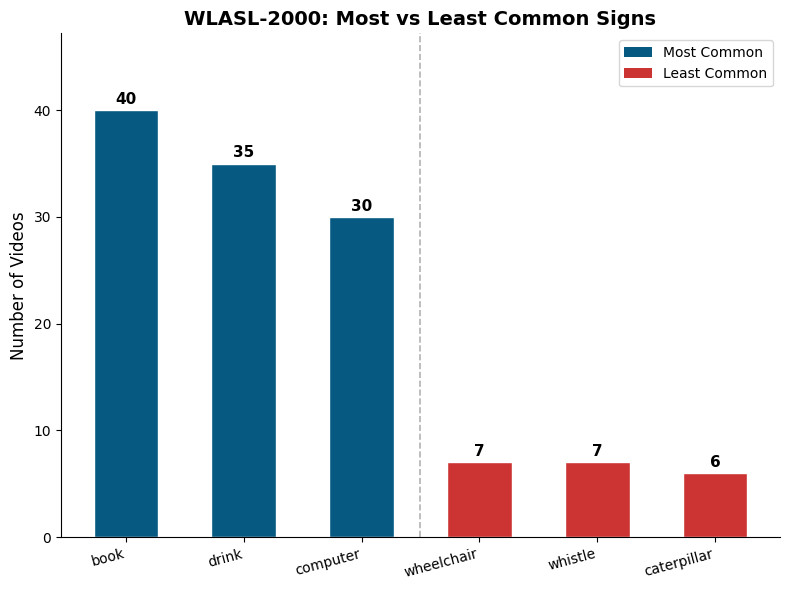

✓ Saved


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.patches import Patch

data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
X, y = data["X"], data["y"]

with open("/content/drive/MyDrive/ASL_Project/wlasl_full_metadata.json", "r") as f:
    metadata = json.load(f)

label_map = metadata["label_map"]
first_v   = list(label_map.values())[0]
if isinstance(first_v, int):
    idx_to_gloss = {v: k for k, v in label_map.items()}
else:
    idx_to_gloss = {int(k): v for k, v in label_map.items()}

class_counts = Counter(y.tolist())
top3    = class_counts.most_common(3)
bottom3 = class_counts.most_common()[:-4:-1][::-1]

combined = top3 + bottom3
labels   = [idx_to_gloss.get(c, f"class_{c}") for c, _ in combined]
counts   = [cnt for _, cnt in combined]
colors   = ["#065A82", "#065A82", "#065A82",
            "#CC3333", "#CC3333", "#CC3333"]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.55)

# Value labels on top of bars
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

# Divider line between top 3 and bottom 3
ax.axvline(x=2.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)

# Legend
legend_elements = [
    Patch(facecolor="#065A82", label="Most Common"),
    Patch(facecolor="#CC3333", label="Least Common"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

ax.set_ylabel("Number of Videos", fontsize=12)
ax.set_title("WLASL-2000: Most vs Least Common Signs", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(counts) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ASL_Project/class_distribution_6_vertical.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved")

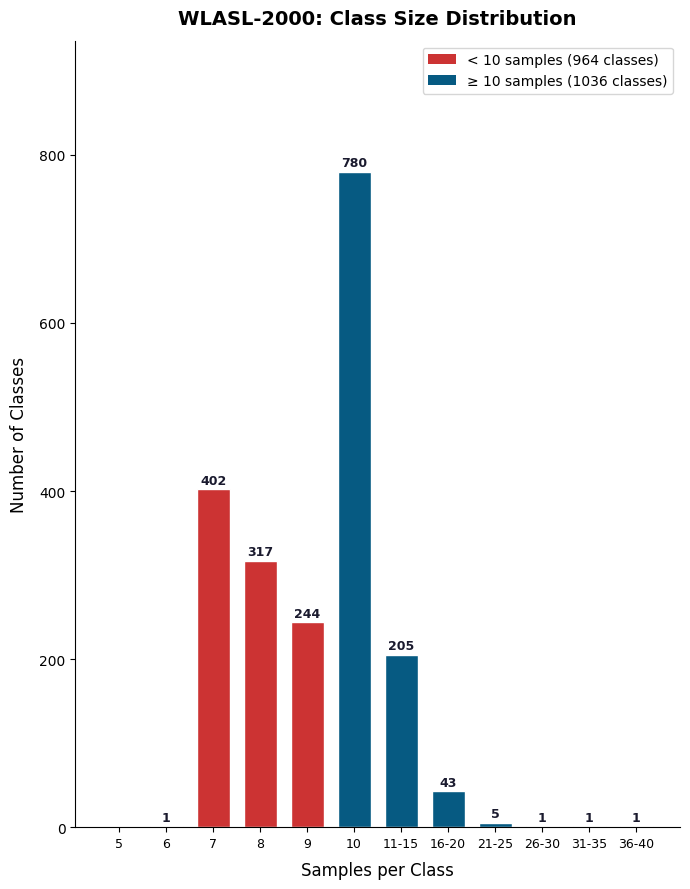

✓ Saved


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
y = data["y"]

class_counts = Counter(y.tolist())
counts_per_class = list(class_counts.values())

# ── Bin edges ─────────────────────────────────────────────────────────────────
bins = [5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45]
bin_labels = ["5","6","7","8","9","10","11-15","16-20","21-25","26-30","31-35","36-40","41-45"]

# Count classes per bin
bin_counts = []
bin_colors = []

for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    if i < len(bins)-2:
        count = sum(1 for c in counts_per_class if lo <= c < hi)
    else:
        count = sum(1 for c in counts_per_class if lo <= c <= hi)
    bin_counts.append(count)
    # Red for <10, blue for ≥10
    bin_colors.append("#CC3333" if hi <= 10 else "#065A82")

# ── Plot vertical ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 9))

bars = ax.bar(range(len(bin_counts)), bin_counts,
              color=bin_colors, edgecolor="white", width=0.7)

# Value labels on top
for bar, val in zip(bars, bin_counts):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 3,
                str(val), ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="#1A1A2E")

# # Divider line between <10 and ≥10
# ax.axvline(x=4.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
# ax.text(4.55, ax.get_ylim()[1] * 0.92, "≥10 samples",
#         fontsize=9, color="#065A82", fontweight="bold",ha="right")
# ax.text(3.45, ax.get_ylim()[1] * 0.92, "<10 samples",
#         fontsize=9, color="#CC3333", fontweight="bold", ha="right")

# Axes
ax.set_xticks(range(len(bin_labels[:-1])))
ax.set_xticklabels(bin_labels[:-1], fontsize=9)
ax.set_xlabel("Samples per Class", fontsize=12, labelpad=8)
ax.set_ylabel("Number of Classes", fontsize=12, labelpad=8)
ax.set_title("WLASL-2000: Class Size Distribution", fontsize=14, fontweight="bold", pad=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#CC3333", label=f"< 10 samples (964 classes)"),
    Patch(facecolor="#065A82", label=f"≥ 10 samples (1036 classes)"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(bin_counts) * 1.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ASL_Project/class_size_histogram.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 1D CNN

Using device: cuda

Loaded 21083 embeddings, shape (21083, 30, 378)
Train: 16866, Val: 4217

Model parameters: 2,959,824



Epoch 1/90 | Loss: 7.4510 | Top-1: 0.38% | Top-5: 1.87% | Top-10: 3.06%


Epoch 2/90 | Loss: 7.0350 | Top-1: 0.83% | Top-5: 3.11% | Top-10: 5.45%


Epoch 3/90 | Loss: 6.7641 | Top-1: 1.40% | Top-5: 5.29% | Top-10: 8.63%


Epoch 4/90 | Loss: 6.5593 | Top-1: 1.92% | Top-5: 7.23% | Top-10: 11.50%


...

Epoch 86/90 | Loss: 2.2711 | Top-1: 28.03% | Top-5: 59.88% | Top-10: 69.79%


Epoch 87/90 | Loss: 2.2679 | Top-1: 28.74% | Top-5: 60.14% | Top-10: 70.17%


Epoch 88/90 | Loss: 2.2768 | Top-1: 28.60% | Top-5: 60.14% | Top-10: 70.10%


Epoch 89/90 | Loss: 2.2733 | Top-1: 28.12% | Top-5: 60.07% | Top-10: 69.69%


Epoch 90/90 | Loss: 2.2632 | Top-1: 28.29% | Top-5: 60.11% | Top-10: 69.98%

Best validation accuracy: 28.74%
Model saved.


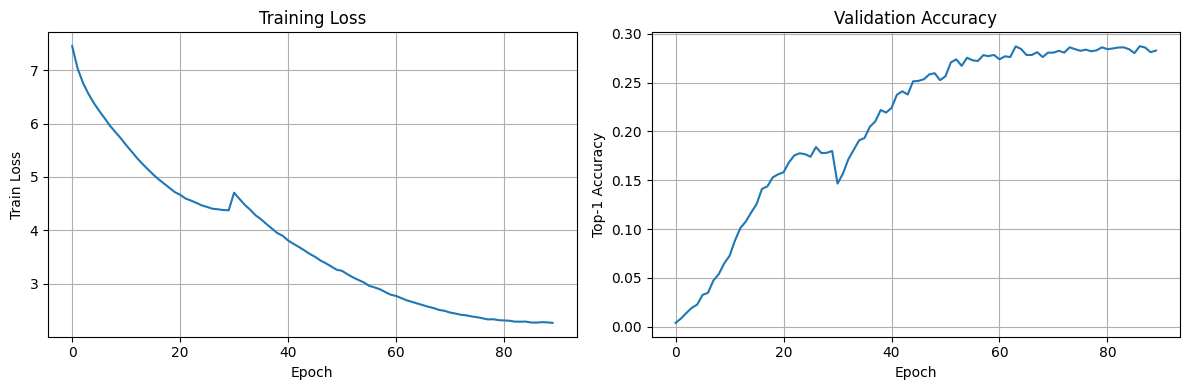

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import top_k_accuracy_score
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

class WLASLDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            num_frames = x.shape[0]
            num_drop = np.random.randint(0, 3)
            if num_drop > 0:
                drop_indices = np.random.choice(num_frames, num_drop, replace=False)
                x[drop_indices] = 0
            x = x + torch.randn_like(x) * 0.005
        return x, self.y[idx]

class ConvNet3D(nn.Module):
    """3D CNN that treats sequence as temporal dimension."""
    def __init__(self, num_classes=2000):
        super().__init__()
        self.conv1 = nn.Conv1d(378, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)

        self.conv2 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(512)

        self.conv4 = nn.Conv1d(512, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(512)
        self.pool4 = nn.MaxPool1d(2)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(512, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, 378, 30)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        x = self.global_avg_pool(x).squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

def train_model(model, train_loader, val_loader, num_epochs=90, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses = []
    val_accs = []
    best_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1} Val", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_preds.append(logits.cpu().numpy())
                val_targets.append(y.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        top1 = (val_preds.argmax(axis=1) == val_targets).mean()
        top5 = top_k_accuracy_score(val_targets, val_preds, k=5)
        top10 = top_k_accuracy_score(val_targets, val_preds, k=10)
        val_accs.append(top1)

        if top1 > best_acc:
            best_acc = top1
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Top-1: {top1*100:.2f}% | Top-5: {top5*100:.2f}% | Top-10: {top10*100:.2f}%")
        scheduler.step()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_accs, best_acc

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")

    data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
    X, y = data["X"], data["y"]
    print(f"Loaded {len(X)} embeddings, shape {X.shape}")

    X_mean = X.mean(axis=(0, 1), keepdims=True)
    X_std = X.std(axis=(0, 1), keepdims=True) + 1e-7
    X = (X - X_mean) / X_std

    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {len(X_train)}, Val: {len(X_val)}\n")

    train_dataset = WLASLDataset(X_train, y_train, augment=True)
    val_dataset = WLASLDataset(X_val, y_val, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

    model = ConvNet3D(num_classes=2000)
    model = model.to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    model, train_losses, val_accs, best_acc = train_model(model, train_loader, val_loader, num_epochs=90, device=device)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss")
    axes[0].set_title("Training Loss")
    axes[0].grid()

    axes[1].plot(val_accs)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Top-1 Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.savefig("convnet_results.png", dpi=150)
    print(f"\nBest validation accuracy: {best_acc*100:.2f}%")
    print("Model saved.")
    torch.save(model.state_dict(), "convnet_model.pt")

Using device: cuda

Loaded 21083 embeddings, shape (21083, 30, 378)
Train: 16866, Val: 4217

Model parameters: 3,056,912



Epoch 1/90 | Loss: 7.4227 | Top-1: 0.38% | Top-5: 1.85% | Top-10: 3.34%


Epoch 2/90 | Loss: 7.0256 | Top-1: 0.66% | Top-5: 3.91% | Top-10: 6.59%


Epoch 3/90 | Loss: 6.6245 | Top-1: 1.78% | Top-5: 7.09% | Top-10: 11.62%


Epoch 4/90 | Loss: 6.2995 | Top-1: 2.63% | Top-5: 9.13% | Top-10: 15.41%


...

Epoch 86/90 | Loss: 1.4909 | Top-1: 23.52% | Top-5: 51.10% | Top-10: 61.11%


Epoch 87/90 | Loss: 1.4931 | Top-1: 23.41% | Top-5: 51.03% | Top-10: 61.30%


Epoch 88/90 | Loss: 1.4896 | Top-1: 23.24% | Top-5: 51.41% | Top-10: 60.80%


Epoch 89/90 | Loss: 1.4850 | Top-1: 23.45% | Top-5: 51.06% | Top-10: 61.11%


Epoch 90/90 | Loss: 1.4870 | Top-1: 23.43% | Top-5: 50.94% | Top-10: 60.94%

Best validation accuracy: 23.62%


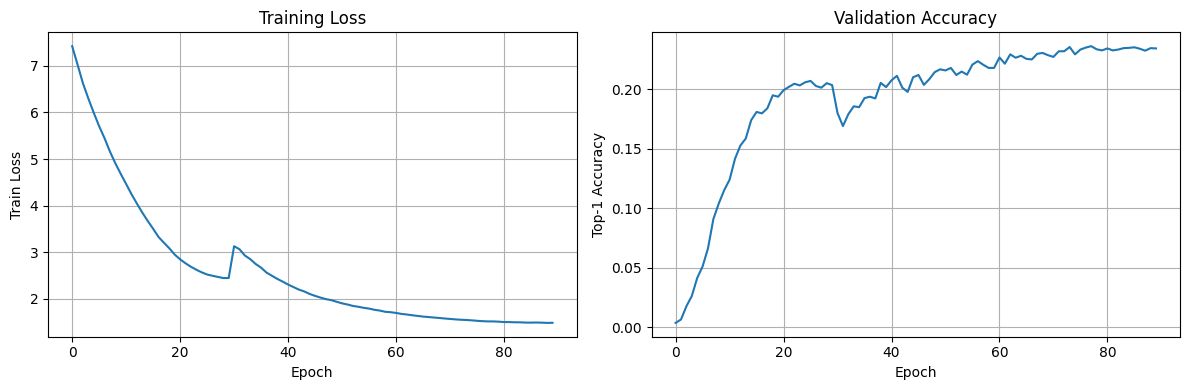

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import top_k_accuracy_score
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

class WLASLDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            num_frames = x.shape[0]
            num_drop = np.random.randint(0, 3)
            if num_drop > 0:
                drop_indices = np.random.choice(num_frames, num_drop, replace=False)
                x[drop_indices] = 0
            x = x + torch.randn_like(x) * 0.005
        return x, self.y[idx]

class TemporalAttentionModule(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.head_dim = dim // num_heads

        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.fc_out = nn.Linear(dim, dim)

    def forward(self, x):
        B, T, C = x.shape

        Q = self.query(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.fc_out(out)

        return out

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, kernel_size=3, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_dim, out_dim, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.conv2 = nn.Conv1d(out_dim, out_dim, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.dropout = nn.Dropout(dropout)

        self.shortcut = nn.Identity()
        if in_dim != out_dim:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_dim, out_dim, 1),
                nn.BatchNorm1d(out_dim)
            )

    def forward(self, x):
        residual = self.shortcut(x)

        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = out + residual
        out = F.gelu(out)

        return out

class DenseNet1D(nn.Module):
    """DenseNet-style architecture with temporal attention."""
    def __init__(self, num_classes=2000):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(378, 64, kernel_size=7, padding=3, stride=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
        )

        # Dense block 1
        self.dense1_conv1 = ResidualBlock(64, 128)
        self.dense1_conv2 = ResidualBlock(64 + 128, 128)
        self.dense1_conv3 = ResidualBlock(64 + 128 + 128, 128)
        self.dense1_transition = nn.Sequential(
            nn.Conv1d(64 + 128 + 128 + 128, 256, kernel_size=1),
            nn.BatchNorm1d(256),
            nn.AvgPool1d(2)
        )

        # Dense block 2
        self.dense2_conv1 = ResidualBlock(256, 128)
        self.dense2_conv2 = ResidualBlock(256 + 128, 128)
        self.dense2_conv3 = ResidualBlock(256 + 128 + 128, 128)
        self.dense2_transition = nn.Sequential(
            nn.Conv1d(256 + 128 + 128 + 128, 256, kernel_size=1),
            nn.BatchNorm1d(256),
        )

        # Temporal attention
        self.temporal_attn = TemporalAttentionModule(256, num_heads=8)

        # Global pooling and classification
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # x: (B, 30, 378)
        x = x.transpose(1, 2)  # (B, 378, 30)

        x = self.stem(x)  # (B, 64, 30)

        # Dense block 1
        x1 = self.dense1_conv1(x)
        x = torch.cat([x, x1], dim=1)
        x2 = self.dense1_conv2(x)
        x = torch.cat([x, x2], dim=1)
        x3 = self.dense1_conv3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.dense1_transition(x)  # (B, 256, 15)

        # Dense block 2
        x1 = self.dense2_conv1(x)
        x = torch.cat([x, x1], dim=1)
        x2 = self.dense2_conv2(x)
        x = torch.cat([x, x2], dim=1)
        x3 = self.dense2_conv3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.dense2_transition(x)  # (B, 256, 15)

        # Temporal attention
        x = x.transpose(1, 2)  # (B, 15, 256)
        x = self.temporal_attn(x)
        x = x.transpose(1, 2)  # (B, 256, 15)

        # Global pooling and classification
        x = self.global_pool(x).squeeze(-1)  # (B, 256)
        x = self.fc(x)

        return x

def train_model(model, train_loader, val_loader, num_epochs=90, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses = []
    val_accs = []
    best_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1} Val", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_preds.append(logits.cpu().numpy())
                val_targets.append(y.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        top1 = (val_preds.argmax(axis=1) == val_targets).mean()
        top5 = top_k_accuracy_score(val_targets, val_preds, k=5)
        top10 = top_k_accuracy_score(val_targets, val_preds, k=10)
        val_accs.append(top1)

        if top1 > best_acc:
            best_acc = top1
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Top-1: {top1*100:.2f}% | Top-5: {top5*100:.2f}% | Top-10: {top10*100:.2f}%")
        scheduler.step()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_accs, best_acc

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")

    data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
    X, y = data["X"], data["y"]
    print(f"Loaded {len(X)} embeddings, shape {X.shape}")

    X_mean = X.mean(axis=(0, 1), keepdims=True)
    X_std = X.std(axis=(0, 1), keepdims=True) + 1e-7
    X = (X - X_mean) / X_std

    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {len(X_train)}, Val: {len(X_val)}\n")

    train_dataset = WLASLDataset(X_train, y_train, augment=True)
    val_dataset = WLASLDataset(X_val, y_val, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

    model = DenseNet1D(num_classes=2000)
    model = model.to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    model, train_losses, val_accs, best_acc = train_model(model, train_loader, val_loader, num_epochs=90, device=device)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss")
    axes[0].set_title("Training Loss")
    axes[0].grid()

    axes[1].plot(val_accs)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Top-1 Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.savefig("densenet_results.png", dpi=150)
    print(f"\nBest validation accuracy: {best_acc*100:.2f}%")
    torch.save(model.state_dict(), "densenet_model.pt")

Using device: cuda

Loaded 21083 embeddings, shape (21083, 30, 378)
Train: 16866, Val: 4217

Model parameters: 2,832,592



Epoch 1/90 | Loss: 7.5163 | Top-1: 0.45% | Top-5: 1.42% | Top-10: 2.63%


Epoch 2/90 | Loss: 7.1232 | Top-1: 0.78% | Top-5: 3.15% | Top-10: 5.95%


Epoch 3/90 | Loss: 6.8260 | Top-1: 1.38% | Top-5: 5.17% | Top-10: 8.99%


Epoch 4/90 | Loss: 6.5487 | Top-1: 2.13% | Top-5: 7.73% | Top-10: 12.92%


...

Epoch 86/90 | Loss: 1.5963 | Top-1: 35.59% | Top-5: 66.47% | Top-10: 75.05%


Epoch 87/90 | Loss: 1.5898 | Top-1: 35.57% | Top-5: 66.87% | Top-10: 75.22%


Epoch 88/90 | Loss: 1.5962 | Top-1: 35.57% | Top-5: 66.82% | Top-10: 74.91%


Epoch 89/90 | Loss: 1.5919 | Top-1: 35.64% | Top-5: 66.90% | Top-10: 75.17%


Epoch 90/90 | Loss: 1.5861 | Top-1: 35.45% | Top-5: 66.59% | Top-10: 75.17%

Best validation accuracy: 35.74%


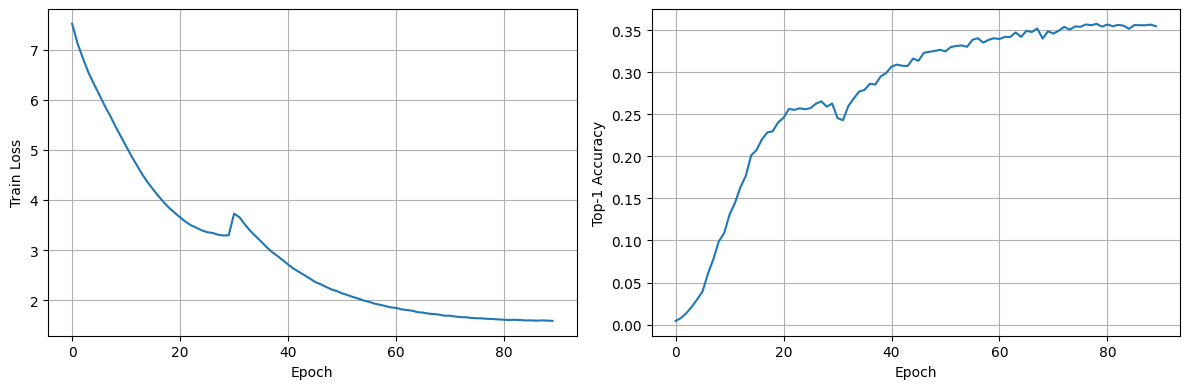

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import top_k_accuracy_score
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

class WLASLDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            num_frames = x.shape[0]
            num_drop = np.random.randint(0, 3)
            if num_drop > 0:
                drop_indices = np.random.choice(num_frames, num_drop, replace=False)
                x[drop_indices] = 0
            x = x + torch.randn_like(x) * 0.005
        return x, self.y[idx]

class DilatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1, dropout=0.2):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size=3,
            padding=dilation, dilation=dilation
        )
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.gelu(self.bn(self.conv(x)))
        x = self.dropout(x)
        return x

class TemporalConvNetwork(nn.Module):
    """TCN with dilations: 1,2,4,8 to capture multi-scale temporal patterns."""
    def __init__(self, num_classes=2000):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(378, 256, kernel_size=1),
            nn.BatchNorm1d(256),
            nn.GELU(),
        )

        # Dilated convolutions: receptive field grows exponentially
        self.dilated_blocks = nn.ModuleList([
            DilatedConvBlock(256, 256, dilation=1),
            DilatedConvBlock(256, 256, dilation=2),
            DilatedConvBlock(256, 256, dilation=4),
            DilatedConvBlock(256, 256, dilation=8),
        ])

        # Multi-scale fusion
        self.fusion = nn.Sequential(
            nn.Conv1d(256 * 5, 512, kernel_size=1),
            nn.BatchNorm1d(512),
            nn.GELU(),
        )

        self.global_pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, 378, 30)

        x = self.stem(x)  # (B, 256, 30)

        # Collect outputs from all dilated blocks
        outputs = [x]
        for block in self.dilated_blocks:
            x = block(x)
            outputs.append(x)

        # Concatenate all scales
        x = torch.cat(outputs, dim=1)  # (B, 256*5, 30)
        x = self.fusion(x)  # (B, 512, 30)

        x = self.global_pool(x).squeeze(-1)  # (B, 512)
        x = self.fc(x)

        return x

def train_model(model, train_loader, val_loader, num_epochs=90, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=2, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses = []
    val_accs = []
    best_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1} Val", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_preds.append(logits.cpu().numpy())
                val_targets.append(y.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        top1 = (val_preds.argmax(axis=1) == val_targets).mean()
        top5 = top_k_accuracy_score(val_targets, val_preds, k=5)
        top10 = top_k_accuracy_score(val_targets, val_preds, k=10)
        val_accs.append(top1)

        if top1 > best_acc:
            best_acc = top1
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Top-1: {top1*100:.2f}% | Top-5: {top5*100:.2f}% | Top-10: {top10*100:.2f}%")
        scheduler.step()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_accs, best_acc

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")

    data = np.load("/content/drive/MyDrive/ASL_Project/wlasl_embeddings_FULL_21k_FIXED2.npz")
    X, y = data["X"], data["y"]
    print(f"Loaded {len(X)} embeddings, shape {X.shape}")

    X_mean = X.mean(axis=(0, 1), keepdims=True)
    X_std = X.std(axis=(0, 1), keepdims=True) + 1e-7
    X = (X - X_mean) / X_std

    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {len(X_train)}, Val: {len(X_val)}\n")

    train_dataset = WLASLDataset(X_train, y_train, augment=True)
    val_dataset = WLASLDataset(X_val, y_val, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

    model = TemporalConvNetwork(num_classes=2000)
    model = model.to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    model, train_losses, val_accs, best_acc = train_model(model, train_loader, val_loader, num_epochs=90, device=device)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss")
    axes[0].grid()

    axes[1].plot(val_accs)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Top-1 Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.savefig("tcn_results.png", dpi=150)
    print(f"\nBest validation accuracy: {best_acc*100:.2f}%")
    torch.save(model.state_dict(), "tcn_model.pt")